# 25 · VAE: encoder가 q를, decoder가 p(x|z)를 계산하는 ELBO 학습

**이번 질문:** 24번의 $q(z \mid x)$와 $p(x \mid z)$를 신경망 두 개로 바꾸면 손실은 무엇이고, 미분은 어디로 흐를까요? 특히 **샘플 $z$를 통과하는 기울기**는 어떻게 계산할까요?

24번에서는 관측 하나마다 $q$의 파라미터 $(\mu, \ell)$을 직접 들고 경사 상승을 했습니다. 관측이 5,000장이면 그런 파라미터가 5,000벌 필요합니다.
이번에는 그 자리에 신경망을 놓습니다. **encoder**는 $x$를 받아 그 관측만의 $(\mu, \ell)$을 내놓고, **decoder**는 잠재 $z$를 받아 화소 784개의 확률을 내놓습니다.
손실은 24번 3절의 두 항 그대로입니다. 새로 할 일은 하나뿐입니다. 중간에 낀 **샘플 $z$를 지나 기울기를 encoder까지 되돌리는 것**입니다.

- 준비물: [03](../00_기초/03_perceptron_to_mlp.ipynb)의 MLP forward·backward와 $dX$, [02](../00_기초/02_probability_and_losses.ipynb)의 sigmoid와 BCE, [12](../02_연결/12_gaussian_information.ipynb)의 대각 KL 닫힌식(5절)과 재매개화 미분(6절), [24](24_elbo.ipynb)의 ELBO 두 항, [04](../00_기초/04_optimizers.ipynb)의 Adam.
- 도착점: NumPy VAE를 손 backward로 만들어 $\epsilon$을 고정한 중심차분으로 검산하고, MNIST 5,000장에서 학습해 복원·생성·보간과 잠재 평면을 봅니다.
- 다음 연결: [28 GAN](28_gan.ipynb)은 같은 "잠재 → 이미지" decoder를 두고, 손실을 하한이 아니라 **판별기와의 겨루기**로 바꿉니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. encoder는 관측마다 $q(z \mid x) = \mathcal{N}(\mu(x),\ \sigma(x)^2)$를 내놓고, 그 사이의 $z$는 **재매개화**로 만듭니다. `z = mu + np.exp(0.5 * logvar) * eps`.
2. 손실은 24번 3절의 두 항이고, **화소 축은 합, 배치 축은 평균**입니다. $-\mathrm{ELBO} = \frac{1}{N}\sum_n\big[\sum_d \mathrm{BCE}(s_{nd}, x_{nd}) + \frac{1}{2}\sum_k(\mu_{nk}^2 + e^{\ell_{nk}} - 1 - \ell_{nk})\big]$.
3. decoder가 돌려준 $dz$는 $\mu$로는 **그대로**, $\ell$로는 $dz \odot \epsilon \odot \sigma / 2$로 갈라집니다. $\epsilon$은 상수라 미분하지 않습니다. `dlogvar = dz * eps * sigma * 0.5 + dlogvar_kl`.

| 기호 | shape | 의미 |
|---|---|---|
| $x$ | $(N, 784)$ | 이미지 배치. 화소 하나가 0–1 사이의 잉크 |
| $h$ | $(N, 256)$ | encoder의 은닉층 |
| $\mu,\ \ell$ | $(N, 2)$ | $q(z \mid x) = \mathcal{N}(\mu, e^{\ell})$의 평균과 로그 분산 |
| $\epsilon$ | $(N, 2)$ | 재매개화에 쓰는 표준정규 잡음. 미분에서는 상수 |
| $z$ | $(N, 2)$ | 잠재 샘플 $\mu + e^{\ell/2}\epsilon$ |
| $g$ | $(N, 256)$ | decoder의 은닉층 |
| $s$ | $(N, 784)$ | decoder가 내는 화소별 logit |

로그의 밑은 $e$이며 정보량의 단위는 nat입니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/vae_plots.py)

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/utils/plotting.py').is_file())   # 현재 폴더부터 위로 올라가며 src/utils/plotting.py가 있는 첫 폴더
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 도우미(01번 3절의 중심차분 numerical_gradient와 상대오차 rel_error), 연습 검사 도우미, 데이터 로더, 이 노트북의 그림 함수(src/utils/vae_plots.py)
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.data.mnist import load_mnist, load_examples
from src.utils.vae_plots import (
    plot_vae_flow, plot_loss_terms, plot_reparam_graph, plot_eps_draws, plot_loss_history,
    plot_recon_pairs, plot_latent_map, plot_mixture_vae, plot_vae_uses, plot_latent_dim_variants,
)

# 3) 그림 설정. 배열 출력은 소수 4자리로 줄여 읽기 쉽게 합니다.
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· VAE 준비 완료")

NumPy 2.4.6 · VAE 준비 완료


### 📎 이 노트북의 예시: MNIST 784 화소, 고정 예시 10장, 두 봉우리 혼합

- **MNIST 5,000장.** 학습에 쓰는 데이터입니다. 화소 하나하나를 "잉크가 있을 확률"로 보고 **Bernoulli**로 모형화합니다. 잠재는 2차원뿐이라 그림 한 장을 숫자 두 개로 줄였다가 되살리게 됩니다. 5,000장·3,000스텝이면 새 커널에서 10초 남짓 걸립니다.
- **고정 예시 10장.** 00번부터 계속 쓰는 숫자 0–9의 고정 이미지입니다. 1절부터 5절까지 같은 7을 따라가며 $(\mu, \sigma)$, $z$, 복원을 봅니다. 학습에는 쓰지 않습니다.
- **2차원 두 봉우리 혼합.** 4절의 🔍 소절에서만 씁니다. 23번에서 만든 이 데이터는 **진짜 밀도를 알고 있어서**, 학습한 하한이 진짜 평균 $\log p(x)$보다 정말 작은지 숫자로 확인할 수 있습니다.

> **용어**
>
> - **MNIST**: 손으로 쓴 숫자 0–9를 28×28 회색조 이미지로 모은 데이터셋. 여기서는 앞 5,000장만 쓰고, 화소 값을 0–1로 맞춰 둡니다.
> - **encoder**: 관측 $x$를 받아 그 관측에 맞는 $q(z \mid x)$의 파라미터 $(\mu, \ell)$을 내놓는 신경망. 24번에서 관측마다 손으로 들고 있던 값을 대신 계산해 줍니다.
> - **decoder**: 잠재 $z$를 받아 $p(x \mid z)$의 파라미터를 내놓는 신경망. 여기서는 화소 784개의 logit입니다.
> - **Bernoulli 관측 모형**: 화소 하나가 0 또는 1이고 1이 될 확률이 $p$인 모형. 회색 화소(0.4 같은 값)도 그대로 넣어 씁니다. 실제로는 "잉크의 진하기"를 확률처럼 쓰는 근사입니다.

> **코드**
>
> - `_`: "받기는 하지만 쓰지 않는다"는 뜻의 변수 이름. `load_mnist()`가 돌려주는 네 개 중 시험 데이터 두 개를 버립니다.
> - `mnist_X_all[:5000]`: 앞에서부터 5,000장만 잘라 쓰는 슬라이스. 이 프로젝트의 공통 관례입니다.
> - `mnist_examples.reshape(10, 784)`: 28×28을 한 줄로 펴서 `@`에 넣을 수 있게 합니다(00번 6절).

아래 두 셀은 실행만 하고 넘어가도 됩니다. 두 번에 나누어 공부해도 됩니다. 먼저 1–3절의 구조·손실·미분을 확인하고, 다음에 4–5절의 학습과 사용을 진행하세요.

In [2]:
mnist_X_all, mnist_y_all, _, _ = load_mnist(download=True)           # (60000, 784), (60000,)
mnist_X = mnist_X_all[:5000]                                          # (5000, 784): 학습에 쓰는 앞 5,000장. 화소는 0–1
mnist_y = mnist_y_all[:5000]                                          # (5000,): 그림에서 색으로만 씁니다 (학습에는 쓰지 않음)
mnist_examples, mnist_labels = load_examples(download=True)           # (10, 28, 28), (10,): 숫자 0–9의 고정 예시
mnist_flat = mnist_examples.reshape(10, 784)                          # (10, 784): 같은 예시를 한 줄로 편 것
print("학습", mnist_X.shape, "· 고정 예시", mnist_examples.shape, "· 7의 잉크 합", mnist_flat[7].sum().round(1))

학습 (5000, 784) · 고정 예시 (10, 28, 28) · 7의 잉크 합 49.5


📎 **참고** · 02번에서 만든 함수 두 개를 여기서 짧게 다시 정의합니다. 노트북은 저마다 혼자 실행되어야 하기 때문입니다. 유도와 그림은 [02번 7절](../00_기초/02_probability_and_losses.ipynb)에 있습니다.

- `sigmoid`: logit $s$를 확률 $p = 1/(1 + e^{-s})$로. 지수가 넘치지 않게 $s$의 부호에 따라 다른 식을 씁니다.
- `softplus`: $\log(1 + e^{s})$. 2절의 BCE를 넘침 없이 쓰는 데 필요합니다.

> **코드**
>
> - `out[positive] = ...`: 불리언 배열로 고른 자리에만 값을 넣습니다(00b 4절). 같은 배열의 나머지 자리는 다음 줄이 채웁니다.
> - `np.log1p(x)`: $\log(1 + x)$를 $x$가 아주 작을 때도 정확하게 계산합니다.
> - `np.maximum(s, 0.0)`: 배열의 각 자리를 0과 비교해 큰 쪽을 남깁니다. 스칼라 하나와 배열을 비교하는 브로드캐스팅입니다.

In [3]:
def sigmoid(s):
    """logit을 확률로: p = 1/(1 + e^{-s}) (02번 7절). 부호에 따라 식을 바꿔 지수가 넘치지 않게 합니다.
    s: 아무 모양의 실수 배열 → 같은 모양, 값은 (0, 1)."""
    s = np.asarray(s, dtype=float)
    out = np.empty_like(s)
    positive = s >= 0                                        # s가 큰 자리: e^{-s}는 0에 가까워 안전
    out[positive] = 1.0 / (1.0 + np.exp(-s[positive]))
    negative_exp = np.exp(s[~positive])                      # s가 작은 자리: e^{s}가 0에 가까워 안전
    out[~positive] = negative_exp / (1.0 + negative_exp)
    return out


def softplus(s):
    """log(1 + e^{s}) 를 넘침 없이: max(s, 0) + log(1 + e^{-|s|}). s: 아무 모양 → 같은 모양, 값은 0 이상."""
    s = np.asarray(s, dtype=float)
    return np.maximum(s, 0.0) + np.log1p(np.exp(-np.abs(s)))

In [4]:
probe_s = np.array([-40.0, -1.0, 0.0, 2.0, 40.0])                     # (5,): 아주 큰 값도 넘치지 않는지 보려고 ±40을 넣었습니다
np.testing.assert_allclose(sigmoid(probe_s), 1.0 / (1.0 + np.exp(-probe_s)))        # 검산: 넘치지 않는 구간에서는 교과서 식과 같음
np.testing.assert_allclose(softplus(np.array([2.0])), [np.log(1 + np.exp(2.0))])    # 검산: 손계산 log(1 + e²) = 2.126928
assert np.all(np.diff(softplus(probe_s)) > 0), "softplus는 증가함수여야 합니다"
assert np.all(np.isfinite(softplus(probe_s))), "softplus는 ±40에서도 유한해야 합니다"
print("sigmoid(0) =", sigmoid(np.array([0.0]))[0], "· softplus(2) =", softplus(np.array([2.0]))[0].round(6))

sigmoid(0) = 0.5 · softplus(2) = 2.126928


## 🔑 1. 구조: 신경망 두 개와 그 사이에서 한 번 뽑는 샘플

**이 절에서 가져갈 것:** encoder는 이미지 하나마다 $(\mu, \ell)$ **두 벌의 숫자**를 내놓고, 그 사이의 잠재는 $z = \mu + \sigma \odot \epsilon$으로 **한 번 뽑습니다**. decoder는 그 $z$ 하나만 보고 화소 784개의 logit을 냅니다. 숫자 두 개를 거쳐 784개가 다시 나오는 좁은 목이 이 구조의 전부입니다.

손글씨 7 한 장을 봅니다. 화소가 784개지만 "어떤 7인가"를 말하는 데 784개가 다 필요하지는 않을 것 같습니다.
기울기, 가로획의 길이 같은 숫자 두어 개면 충분할 것 같습니다. 그 숫자 두 개를 **찾아 주는 신경망**이 encoder이고, 그 숫자 두 개로 **그림을 다시 그리는 신경망**이 decoder입니다.

24번과 달라지는 것은 하나뿐입니다. 24번의 $q$는 관측 하나에 붙은 파라미터였지만, 여기서는 $q$의 파라미터가 **$x$의 함수**입니다. 이미지를 넣으면 그 이미지에 맞는 $(\mu, \ell)$이 나옵니다.

> **용어**
>
> - **잠재 차원(latent dimension)** $L$: $z$에 들어가는 숫자의 개수. 여기서는 $L = 2$라 잠재를 평면 위의 점으로 그릴 수 있습니다.
> - **로그 분산** $\ell = \log \sigma^2$: 분산 대신 그 로그를 파라미터로 둡니다. 신경망이 어떤 값을 내놓아도 $\sigma = e^{\ell/2} > 0$이 저절로 지켜집니다(24번 5절).
> - **재매개화(reparameterization)**: "$q$에서 $z$를 뽑는다"를 "표준정규 $\epsilon$을 뽑아 $\mu + \sigma\epsilon$으로 옮긴다"로 다시 쓰는 것(12번 6절). 3절에서 미분이 이 길을 따라 흐릅니다.
> - **logit** $s$: 확률이 되기 전의 점수. $p = \mathrm{sigmoid}(s)$입니다(02번 7절).

encoder는 03번의 MLP 한 벌인데 **머리가 둘**입니다. 은닉층 하나를 공유하고, 거기서 $\mu$와 $\ell$을 따로 뽑습니다. 인덱스로 쓰면

$$h_{nj} = \tanh\Big(\sum_{d} x_{nd} W^{(1)}_{dj} + b^{(1)}_j\Big), \qquad
\mu_{nk} = \sum_{j} h_{nj} W^{\mu}_{jk} + b^{\mu}_k, \qquad
\ell_{nk} = \sum_{j} h_{nj} W^{\ell}_{jk} + b^{\ell}_k$$

이고, 배열 식으로는 `H = np.tanh(X @ W1 + b1)`, `mu = H @ Wmu + bmu`, `logvar = H @ Wlv + blv` 입니다. $n$은 배치 안의 이미지 번호, $d$는 화소 번호, $j$는 은닉 단위 번호, $k$는 잠재 번호입니다.

샘플은 잠재 성분마다 따로 뽑습니다.

$$\sigma_{nk} = e^{\ell_{nk}/2}, \qquad z_{nk} = \mu_{nk} + \sigma_{nk}\,\epsilon_{nk}, \qquad \epsilon_{nk} \sim \mathcal{N}(0, 1).$$

decoder는 반대 방향의 MLP 한 벌입니다. $(N, 2) \to (N, 256) \to (N, 784)$.

$$g_{nj} = \tanh\Big(\sum_{k} z_{nk} W^{(2)}_{kj} + b^{(2)}_j\Big), \qquad
s_{nd} = \sum_{j} g_{nj} W^{(3)}_{jd} + b^{(3)}_d, \qquad p_{nd} = \mathrm{sigmoid}(s_{nd}).$$

아래 셀은 아직 함수 없이, 고정 예시 7 한 장을 **학습 전 파라미터**로 직접 통과시켜 봅니다.

> **코드**
>
> - `rng.normal(size=(784, hidden)) * np.sqrt(1.0 / 784)`: 04번 9절의 초기화. 들어오는 값의 개수 $D$로 표준편차를 $\sqrt{1/D}$로 정해 층을 지날 때 크기가 유지되게 합니다(04번 9절의 $\mathrm{Var}(z) = D\,\mathrm{Var}(w)\,\mathbb{E}[a^2]$).
> - `mnist_flat[7:8]`: 7 한 장을 `(784,)`가 아니라 `(1, 784)`로 남기는 슬라이스입니다. 배치 축을 유지해야 `@`가 그대로 통합니다.

In [5]:
def init_vae(latent=2, hidden=256, in_dim=784, seed=2501):
    """VAE 파라미터 사전. encoder는 W1·b1 뒤에 (Wmu, bmu)와 (Wlv, blv) 두 머리, decoder는 W2·b2·W3·b3.
    latent: 잠재 차원 L, hidden: 은닉 폭, in_dim: 화소 수 D → 키 10개의 사전."""
    rng = np.random.default_rng(seed)
    return {"W1": rng.normal(size=(in_dim, hidden)) * np.sqrt(1.0 / in_dim), "b1": np.zeros(hidden),
            "Wmu": rng.normal(size=(hidden, latent)) * np.sqrt(1.0 / hidden), "bmu": np.zeros(latent),
            "Wlv": rng.normal(size=(hidden, latent)) * np.sqrt(1.0 / hidden), "blv": np.zeros(latent),
            "W2": rng.normal(size=(latent, hidden)) * np.sqrt(1.0 / latent), "b2": np.zeros(hidden),
            "W3": rng.normal(size=(hidden, in_dim)) * np.sqrt(1.0 / hidden), "b3": np.zeros(in_dim)}

In [6]:
# 쓰는 것: mnist_flat (📎 데이터 셀) · sigmoid (📎 02번 함수 셀)
start_p = init_vae()                                                  # 학습 전 파라미터. 4절에서 이 값에서 출발합니다
start_H = np.tanh(mnist_flat[7:8] @ start_p["W1"] + start_p["b1"])    # (1, 256): encoder 은닉층
start_mu = start_H @ start_p["Wmu"] + start_p["bmu"]                  # (1, 2): q의 평균
start_logvar = start_H @ start_p["Wlv"] + start_p["blv"]              # (1, 2): q의 로그 분산 ℓ
start_sigma = np.exp(0.5 * start_logvar)                              # (1, 2): σ = e^{ℓ/2} > 0
start_eps = np.random.default_rng(2504).normal(size=(1, 2))           # (1, 2): 이번에 뽑은 잡음 하나
start_z = start_mu + start_sigma * start_eps                          # (1, 2): 재매개화 샘플
start_G = np.tanh(start_z @ start_p["W2"] + start_p["b2"])            # (1, 256): decoder 은닉층
start_logits = start_G @ start_p["W3"] + start_p["b3"]                # (1, 784): 화소별 logit s
start_prob = sigmoid(start_logits)                                    # (1, 784): 화소별 확률 p
print("μ", start_mu[0], "· σ", start_sigma[0], "· ε", start_eps[0], "· z", start_z[0])
print("logit 범위", start_logits.min().round(2), "…", start_logits.max().round(2), "· 확률 평균", start_prob.mean().round(4))

μ [-0.1316 -0.4512] · σ [0.7991 1.0471] · ε [-0.2829 -0.0684] · z [-0.3576 -0.5229]
logit 범위 -1.01 … 1.12 · 확률 평균 0.5021


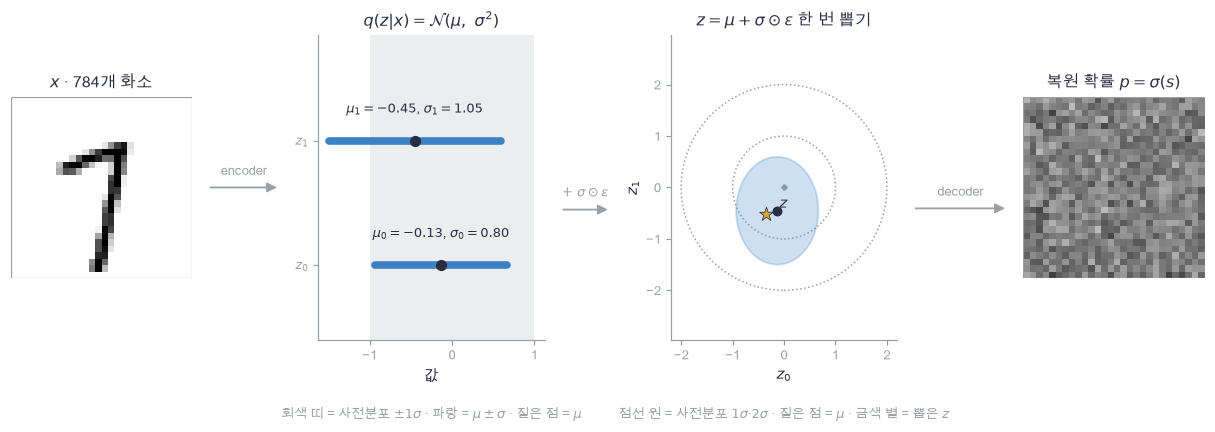

In [7]:
plot_vae_flow(mnist_examples[7], start_mu[0], start_sigma[0], start_z[0], start_prob.reshape(28, 28))

🔍 **확인** · 왼쪽 7이 encoder를 지나 숫자 네 개($\mu_0, \mu_1, \sigma_0, \sigma_1$)가 되었습니다. 두 번째 판의 파란 막대가 $\mu_k \pm \sigma_k$(막대 가운데 짙은 점이 $\mu_k$)이고, 회색 띠가 사전분포 $\mathcal{N}(0, 1)$의 $\pm 1\sigma$입니다. 학습 전이라 $q$가 사전분포와 거의 같은 자리에 있습니다.
세 번째 판에서 금색 별이 이번에 뽑은 $z$입니다(금색은 이 별 하나뿐이고, $\mu$는 두 판 모두 짙은 점입니다). $\mu$에서 $\sigma \odot \epsilon$만큼 흔들린 자리인데, 이번 $\epsilon$이 $(-0.28, -0.07)$이라 $\mu$ 바로 옆에 붙어 있습니다. **같은 $x$를 다시 넣어도 $\epsilon$이 달라지면 다른 자리**가 됩니다(4절에서 다시 봅니다).
맨 오른쪽이 그 $z$ 하나로 그린 784개 확률입니다. 아직 학습 전이라 잡음일 뿐입니다. 확률의 평균이 0.50이고 잉크가 있어야 할 자리와 아닌 자리가 전혀 구별되지 않습니다. 4절에서 이 판이 7처럼 변합니다.

아래는 위 셀의 계산을 배치 전체에 쓸 수 있게 함수로 묶은 것입니다. encoder와 decoder를 따로 두고, backward에 필요한 은닉층은 돌려주어 캐시로 씁니다.

In [8]:
def encoder_forward(X, p):
    """encoder: 은닉층 하나를 공유하고 μ와 ℓ 두 머리로 나뉩니다. H = tanh(X W1 + b1), μ = H Wmu + bmu, ℓ = H Wlv + blv.
    X: (N, D), p: 파라미터 사전 → (mu: (N, L), logvar: (N, L), H: (N, hidden))."""
    H = np.tanh(X @ p["W1"] + p["b1"])
    return H @ p["Wmu"] + p["bmu"], H @ p["Wlv"] + p["blv"], H


def reparameterize(mu, logvar, eps):
    """재매개화: σ = e^{ℓ/2}, z = μ + σ ⊙ ε (12번 6절). ε은 바깥에서 뽑아 넣습니다(미분에서 상수로 두기 위해서).
    mu·logvar·eps: 모두 (N, L) → (z: (N, L), sigma: (N, L))."""
    sigma = np.exp(0.5 * logvar)
    return mu + sigma * eps, sigma

In [9]:
def decoder_forward(Z, p):
    """decoder: G = tanh(Z W2 + b2), s = G W3 + b3. 확률이 아니라 logit을 돌려줍니다(2절 BCE가 logit을 받습니다).
    Z: (N, L), p: 파라미터 사전 → (logits: (N, D), G: (N, hidden))."""
    G = np.tanh(Z @ p["W2"] + p["b2"])
    return G @ p["W3"] + p["b3"], G

In [10]:
# 쓰는 것: mnist_flat (📎 데이터 셀) · start_p, start_mu, start_logvar, start_eps, start_z, start_logits (1절 계산 셀)
check_mu, check_logvar, check_H = encoder_forward(mnist_flat, start_p)      # (10, 2), (10, 2), (10, 256): 고정 예시 10장
check_z, check_sigma = reparameterize(check_mu, check_logvar, np.zeros_like(check_mu))
check_logits, check_G = decoder_forward(check_mu, start_p)
assert check_mu.shape == (10, 2), "encoder는 이미지마다 잠재 2개의 평균을 내야 합니다"
assert check_logits.shape == (10, 784), "decoder는 이미지마다 화소 784개의 logit을 내야 합니다"
assert np.all(check_sigma > 0), "σ = e^{ℓ/2}는 ℓ이 어떤 값이든 양수여야 합니다"
np.testing.assert_allclose(check_z, check_mu)                              # 검산: ε = 0이면 z는 정확히 μ
np.testing.assert_allclose(encoder_forward(mnist_flat[7:8], start_p)[0], start_mu)     # 검산: 위 계산 셀의 μ와 같음
np.testing.assert_allclose(reparameterize(start_mu, start_logvar, start_eps)[0], start_z)   # 검산: 위 계산 셀의 z와 같음
np.testing.assert_allclose(decoder_forward(start_z, start_p)[0], start_logits)              # 검산: 위 계산 셀의 logit과 같음
print("shape 흐름:", mnist_flat.shape, "→", check_mu.shape, "×2 →", check_z.shape, "→", check_logits.shape)

shape 흐름: (10, 784) → (10, 2) ×2 → (10, 2) → (10, 784)


### ✏️ 연습 1 · 샘플 하나를 만드는 한 줄

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.** `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요. 아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

평균 `mu` `(N, L)`, 로그 분산 `logvar` `(N, L)`, 미리 뽑아 둔 잡음 `eps` `(N, L)`에서 재매개화 샘플 `z` `(N, L)`를 만드는 한 줄을 채우세요. $\sigma$를 먼저 만들 필요는 없습니다. 검사는 $\sigma = (1, 2)$가 되는 손계산과 1절 계산 셀의 `start_z`로 합니다.

In [11]:
def exercise_reparameterize(mu, logvar, eps):
    """연습 1: 재매개화 샘플 z = μ + e^{ℓ/2} ⊙ ε. mu·logvar·eps: 모두 (N, L) → z: (N, L)."""
    assert mu.shape == logvar.shape, "mu와 logvar는 같은 (N, L)이어야 합니다"
    assert eps.shape == mu.shape, "eps도 mu와 같은 (N, L)이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: z = μ + e^{ℓ/2} ⊙ ε (모양 (N, L))
    ### 힌트: 1절 reparameterize의 두 줄을 한 줄로 합친 것입니다. np.exp(0.5 * logvar)가 σ입니다.
    raise NotImplementedError
    return z

In [12]:
def check_reparameterize(candidate):
    """σ = (1, 2)가 되는 손계산과 1절 계산 셀의 z로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: start_mu, start_logvar, start_eps, start_z (1절 계산 셀)
    example_mu = np.array([[0.5, -1.0]])                             # (1, 2)
    example_logvar = np.array([[0.0, np.log(4.0)]])                  # (1, 2): σ = (1, 2)
    example_eps = np.array([[1.0, -0.5]])                            # (1, 2)
    actual = candidate(example_mu, example_logvar, example_eps)
    assert actual.shape == (1, 2), f"z의 모양은 (N, L) = (1, 2)여야 하는데 {actual.shape}입니다"
    np.testing.assert_allclose(actual, [[1.5, -2.0]])                # 검산: 손계산 0.5 + 1·1 = 1.5, −1 + 2·(−0.5) = −2
    np.testing.assert_allclose(candidate(start_mu, start_logvar, start_eps), start_z)   # 검산: 1절 계산 셀의 z
    np.testing.assert_allclose(candidate(start_mu, start_logvar, np.zeros_like(start_mu)), start_mu)   # 검산: ε = 0이면 μ
    print("재매개화 한 줄: 손계산·1절 reparameterize와 일치합니다.")

run_check(check_reparameterize, exercise_reparameterize, hint="z = mu + np.exp(0.5 * logvar) * eps")

☐ exercise_reparameterize: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: z = mu + np.exp(0.5 * logvar) * eps


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
z = mu + np.exp(0.5 * logvar) * eps
```

</details>

## 🔑 2. 목적: 재구성 항과 KL 항, 어느 축을 더하고 어느 축을 평균내나

**이 절에서 가져갈 것:** 최소화할 값은 $-\mathrm{ELBO}$이고, 24번 3절의 두 항 그대로입니다. **화소 축은 더하고(합), 배치 축은 나눕니다(평균).** 재구성 항은 화소마다의 BCE 784개를 더한 것이고, KL 항은 12번 5절의 대각 닫힌식입니다.

7 한 장을 복원했다고 합시다. "얼마나 잘 복원했나"를 숫자 하나로 만들어야 합니다.
화소 784개마다 "잉크가 있을 확률을 얼마로 말했나"를 벌점으로 재고 **784개를 모두 더합니다**. 이미지 하나가 벌점 하나를 받습니다.
배치에 이미지가 100장이면 그 벌점 100개를 **평균**냅니다. 배치 크기를 바꿔도 손실의 크기가 그대로이게 하려는 것입니다(14번 2절의 규약).

> **용어**
>
> - **재구성 항(reconstruction term)**: $-\log p(x \mid z)$. "지금 뽑은 $z$로 $x$를 얼마나 잘 설명하나"의 벌점입니다.
> - **BCE (binary cross-entropy)**: 정답 $x \in [0, 1]$과 예측 확률 $p$ 사이의 벌점 $-[x\log p + (1-x)\log(1-p)]$ (02번 7절).
> - **KL 항**: $D_{KL}(q(z \mid x)\,\|\,\mathcal{N}(0, I))$. "$q$가 사전분포에서 얼마나 멀어졌나"의 벌점입니다(24번 3절).

$p = \mathrm{sigmoid}(s)$를 넣어 정리하면 BCE는 logit만으로 깔끔하게 써집니다. $\log(1-\mathrm{sigmoid}(s)) = -\mathrm{softplus}(s)$이고 $\log \mathrm{sigmoid}(s) = s - \mathrm{softplus}(s)$이므로

$$\mathrm{BCE}(s, x) = -\big[x\log p + (1-x)\log(1-p)\big] = \mathrm{softplus}(s) - x\,s, \qquad \frac{\partial\,\mathrm{BCE}}{\partial s} = \mathrm{sigmoid}(s) - x.$$

이 꼴은 $s$가 $\pm 40$이어도 넘치지 않습니다. 잠재 쪽은 12번 5절 닫힌식에서 $p$를 표준정규로 둔 특수형입니다.

$$D_{KL}\big(\mathcal{N}(\mu, e^{\ell})\,\|\,\mathcal{N}(0, 1)\big) = \tfrac12\big(\mu^2 + e^{\ell} - 1 - \ell\big), \qquad
\frac{\partial\,\mathrm{KL}}{\partial \mu} = \mu, \qquad \frac{\partial\,\mathrm{KL}}{\partial \ell} = \tfrac12(e^{\ell} - 1).$$

두 항을 합치면 배치 하나의 손실입니다. $D$는 화소 수, $L$은 잠재 차원입니다.

$$L(x, s, \mu, \ell) = \frac{1}{N}\sum_{n=0}^{N-1}\Big[\underbrace{\sum_{d=0}^{D-1}\big(\mathrm{softplus}(s_{nd}) - x_{nd}s_{nd}\big)}_{\text{재구성 항}} + \underbrace{\frac12\sum_{k=0}^{L-1}\big(\mu_{nk}^2 + e^{\ell_{nk}} - 1 - \ell_{nk}\big)}_{\text{KL 항}}\Big].$$

먼저 손으로 셀 수 있는 크기로 확인합니다. **화소 2개, 잠재 1개, 이미지 1장**입니다.

In [13]:
# 쓰는 것: softplus (📎 02번 함수 셀)
hand_x = np.array([[1.0, 0.0]])                                       # (1, 2): 화소 두 개. 왼쪽은 잉크 있음, 오른쪽은 없음
hand_s = np.array([[2.0, -1.0]])                                      # (1, 2): decoder가 낸 logit
hand_mu = np.array([[0.5]])                                           # (1, 1): 잠재 하나의 평균
hand_logvar = np.array([[-0.4]])                                      # (1, 1): 잠재 하나의 로그 분산
hand_bce = softplus(hand_s) - hand_x * hand_s                         # (1, 2): 화소마다의 벌점
hand_recon = float(hand_bce.sum())                                    # 화소 축의 합 = 이미지 한 장의 재구성 항
hand_kl = float(0.5 * np.sum(hand_mu ** 2 + np.exp(hand_logvar) - 1.0 - hand_logvar))
print("화소별 BCE", hand_bce[0].round(6), "→ 재구성", round(hand_recon, 6))
print("KL = ½(0.25 + e^{−0.4} − 1 + 0.4) =", round(hand_kl, 6), "· 합 =", round(hand_recon + hand_kl, 6))

화소별 BCE [0.1269 0.3133] → 재구성 0.44019
KL = ½(0.25 + e^{−0.4} − 1 + 0.4) = 0.16016 · 합 = 0.60035


In [14]:
# 쓰는 것: mnist_X, mnist_flat (📎 데이터 셀) · softplus (📎 02번 함수 셀) · start_logits, start_mu, start_logvar (1절 계산 셀)
mean_prob = np.clip(mnist_X.mean(axis=0), 0.01, 0.99)                 # (784,): 5,000장의 평균 이미지. 0과 1은 로그가 발산해 잘라 냅니다
mean_logit = np.log(mean_prob / (1.0 - mean_prob))                    # (784,): 그 확률을 내는 logit (sigmoid의 역)
near_prob = 0.05 + 0.9 * mnist_flat[7]                                # (784,): 정답을 거의 맞힌 후보 (0.05–0.95로 눌러 둔 x)
near_logit = np.log(near_prob / (1.0 - near_prob))                    # (784,)
candidate_names = ["평균 이미지", "학습 전", "거의 맞힘"]
candidate_bce = [softplus(logit) - mnist_flat[7] * logit for logit in [mean_logit, start_logits[0], near_logit]]
candidate_recon = [float(np.sum(bce)) for bce in candidate_bce]       # 후보마다 화소 784개를 더한 재구성 항
start_kl_one = float(0.5 * np.sum(start_mu ** 2 + np.exp(start_logvar) - 1.0 - start_logvar))
print("재구성 항", [round(v, 2) for v in candidate_recon], "· 학습 전 KL 항", round(start_kl_one, 4))

재구성 항 [156.73, 559.0, 68.75] · 학습 전 KL 항 0.1562


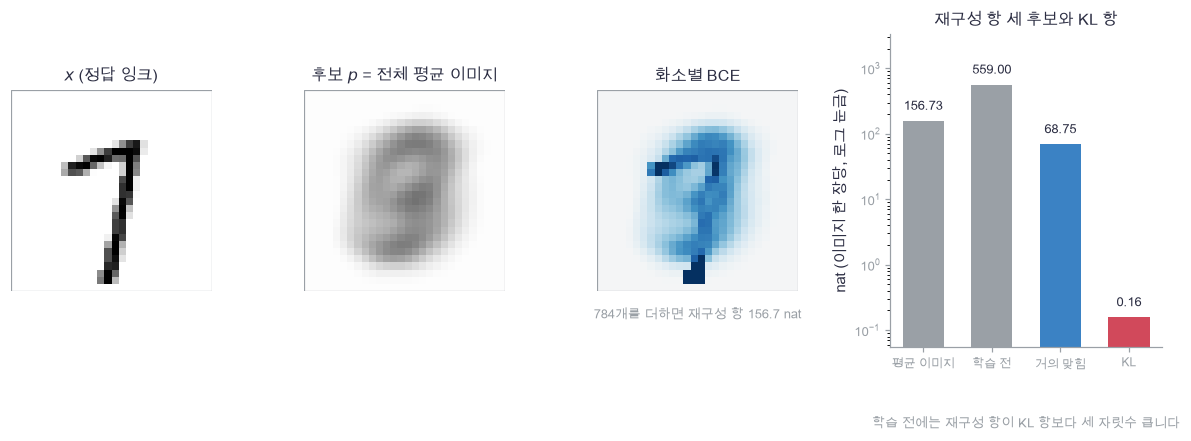

In [15]:
plot_loss_terms(mnist_examples[7], mean_prob.reshape(28, 28), candidate_bce[0].reshape(28, 28),
                "후보 $p$ = 전체 평균 이미지", candidate_names, candidate_recon, start_kl_one)

🔍 **확인** · 가운데 두 판은 후보 하나("모든 이미지에 같은 평균 이미지를 내놓는 decoder")의 확률과 그 화소별 BCE입니다. **BCE 지도에 7이 보입니다.** 평균 이미지에는 없는데 이 7에는 잉크가 있는 자리, 그리고 그 반대인 자리에서 벌점이 큽니다. 잘 맞힌 배경 화소는 거의 0입니다.
오른쪽 막대는 로그 눈금입니다. 같은 7에 대해 재구성 항이 평균 이미지 후보 156.7, 학습 전 decoder 559.0, 거의 맞힌 후보 68.8 nat입니다. **잘 복원할수록 작아지는 숫자**가 맞습니다.
가장 오른쪽 빨간 막대가 KL 항 0.16 nat입니다. 재구성 항보다 **세 자릿수 작습니다.** 화소가 784개인데 잠재는 2개뿐이라 그렇습니다. 4절에서 이 불균형이 잠재 분포의 모양을 어떻게 바꾸는지 보게 됩니다.

아래 구현은 두 항과 함께 **뒤로 보낼 기울기 세 개**도 같이 돌려줍니다. 배치 평균의 $1/N$은 여기서 한 번만 곱해 두고, 3절의 backward는 그 값을 그대로 이어받습니다.

In [16]:
def vae_loss(X, logits, mu, logvar):
    """배치 하나의 −ELBO와 그 기울기. 화소 축은 합, 배치 축은 평균(1/N을 여기서 한 번만 곱합니다).
    X·logits: (N, D), mu·logvar: (N, L)
    → (loss, recon, kl: 숫자 셋, dlogits: (N, D), dmu_kl: (N, L), dlogvar_kl: (N, L))."""
    # 쓰는 것: softplus, sigmoid (📎 02번 함수 셀)
    N = len(X)
    recon = float(np.sum(softplus(logits) - X * logits) / N)          # Σ_d BCE 를 배치 평균
    kl = float(0.5 * np.sum(mu ** 2 + np.exp(logvar) - 1.0 - logvar) / N)
    dlogits = (sigmoid(logits) - X) / N                               # (N, D): ∂BCE/∂s = sigmoid(s) − x
    dmu_kl = mu / N                                                   # (N, L): ∂KL/∂μ = μ
    dlogvar_kl = 0.5 * (np.exp(logvar) - 1.0) / N                     # (N, L): ∂KL/∂ℓ = ½(e^ℓ − 1)
    return recon + kl, recon, kl, dlogits, dmu_kl, dlogvar_kl

In [17]:
# 쓰는 것: sigmoid (📎 02번 함수 셀) · hand_x, hand_s, hand_mu, hand_logvar, hand_recon, hand_kl (2절 손계산 셀)
loss_value, recon_value, kl_value, hand_dlogits, hand_dmu_kl, hand_dlogvar_kl = vae_loss(hand_x, hand_s, hand_mu, hand_logvar)
np.testing.assert_allclose([recon_value, kl_value], [hand_recon, hand_kl])          # 검산: 위 손계산과 같은 두 항
np.testing.assert_allclose(hand_dlogits, [[-0.11920292, 0.26894142]])               # 검산: 손계산 sigmoid(2) − 1, sigmoid(−1) − 0
np.testing.assert_allclose(hand_dmu_kl, [[0.5]])                                    # 검산: ∂KL/∂μ = μ = 0.5
np.testing.assert_allclose(hand_dlogvar_kl, [[0.5 * (np.exp(-0.4) - 1.0)]])         # 검산: ∂KL/∂ℓ = ½(e^{−0.4} − 1) = −0.16484
probability = sigmoid(hand_s)                                                       # (1, 2): 같은 logit을 확률로
textbook_bce = -(hand_x * np.log(probability) + (1 - hand_x) * np.log(1 - probability))   # 02번 7절의 확률 형태
np.testing.assert_allclose(np.sum(textbook_bce), hand_recon)                        # 검산: softplus 형태 = 02번의 확률 형태
print(f"−ELBO = 재구성 {recon_value:.6f} + KL {kl_value:.6f} = {loss_value:.6f}")

−ELBO = 재구성 0.440190 + KL 0.160160 = 0.600350


In [18]:
# 쓰는 것: hand_mu, hand_logvar, hand_kl (2절 손계산 셀)
mc_rng = np.random.default_rng(2506)
mc_z = hand_mu + np.exp(0.5 * hand_logvar) * mc_rng.normal(size=(1, 400000))        # (1, 400000): q에서 뽑은 z
mc_log_q = -0.5 * (np.log(2 * np.pi * np.exp(hand_logvar)) + (mc_z - hand_mu) ** 2 / np.exp(hand_logvar))
mc_log_prior = -0.5 * (np.log(2 * np.pi) + mc_z ** 2)                               # log N(z; 0, 1)
mc_kl = float(np.mean(mc_log_q - mc_log_prior))                                     # KL = E_q[log q − log p] (12번 5절)
assert abs(mc_kl - hand_kl) < 0.01, "40만 샘플로 잰 KL이 닫힌식과 0.01 안에서 같아야 합니다"
print(f"KL 닫힌식 {hand_kl:.6f} · 40만 샘플 추정 {mc_kl:.6f} · 차이 {mc_kl - hand_kl:+.6f}")

KL 닫힌식 0.160160 · 40만 샘플 추정 0.159542 · 차이 -0.000618


### ✏️ 연습 2 · 화소는 더하고 배치는 나눕니다

이미지 `X` `(N, D)`와 decoder logit `logits` `(N, D)`에서 배치 하나의 **재구성 항** 숫자 하나를 만드는 한 줄을 채우세요. 화소 축은 더하고 배치 축은 나눕니다. 검사는 이미지 2장·화소 2개의 손계산과 2절 `vae_loss`로 합니다.

In [19]:
def exercise_recon_term(X, logits):
    """연습 2: 배치의 재구성 항 = (화소 축 합)을 배치 축으로 평균낸 숫자 하나. X·logits: (N, D) → 숫자."""
    assert X.shape == logits.shape, "X와 logits는 같은 (N, D)여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: recon = softplus(logits) − X ⊙ logits 를 전부 더한 뒤 이미지 수 N으로 나눈 숫자
    ### 힌트: 2절 vae_loss의 recon 줄입니다. np.sum(...)은 두 축을 모두 더하고, 나눌 N은 len(X)입니다.
    raise NotImplementedError
    return recon

In [20]:
def check_recon_term(candidate):
    """이미지 2장·화소 2개의 손계산과 2절 vae_loss로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: vae_loss (2절) · mnist_flat (📎 데이터 셀) · start_logits (1절 계산 셀)
    example_X = np.array([[1.0, 0.0], [0.0, 1.0]])                    # (2, 2)
    example_logits = np.array([[2.0, -1.0], [0.0, 3.0]])              # (2, 2)
    actual = candidate(example_X, example_logits)
    assert np.ndim(actual) == 0, f"재구성 항은 숫자 하나여야 하는데 모양이 {np.shape(actual)}입니다"
    np.testing.assert_allclose(actual, 0.59096212)                    # 검산: 손계산 (0.4401897 + 0.7417345) / 2
    reference = vae_loss(mnist_flat[7:8], start_logits, np.zeros((1, 2)), np.zeros((1, 2)))[1]
    np.testing.assert_allclose(candidate(mnist_flat[7:8], start_logits), reference)   # 검산: 2절 vae_loss의 recon
    print("재구성 항의 두 축: 손계산·vae_loss와 일치합니다.")

run_check(check_recon_term, exercise_recon_term, hint="recon = np.sum(softplus(logits) - X * logits) / len(X)")

☐ exercise_recon_term: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: recon = np.sum(softplus(logits) - X * logits) / len(X)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
recon = np.sum(softplus(logits) - X * logits) / len(X)
```

</details>

## 🔑 3. backward: 샘플 $z$를 지나 $\mu$와 $\ell$ 두 갈래로

**이 절에서 가져갈 것:** decoder backward가 돌려준 $dz$는 $\mu$로 **그대로** 가고, $\ell$로는 $dz \odot \epsilon \odot \sigma / 2$가 되어 갑니다. 거기에 KL 항의 기울기를 더한 뒤 encoder backward로 보냅니다. $\epsilon$은 뽑아 놓은 상수라 미분하지 않습니다.

중간에 "뽑기"가 끼어 있으면 미분이 막힐 것 같습니다. 재매개화가 그 걱정을 없앱니다.
$\epsilon$을 먼저 뽑아 **고정해 두면** $z = \mu + e^{\ell/2}\epsilon$은 $\mu$와 $\ell$의 평범한 함수이고, 03번에서 쓰던 연쇄법칙이 그대로 통합니다(12번 6절의 pathwise 미분).

> **용어**
>
> - **pathwise 미분**: 잡음을 고정해 놓고 그 경로를 따라 미분하는 것. 같은 $\epsilon$을 쓰는 한 forward와 backward가 짝이 맞습니다.
> - **캐시(cache)**: backward에 필요해서 forward가 남겨 두는 중간값. 여기서는 $H, G, z, \mu, \ell, \sigma, \epsilon$입니다(03번 4절).

$z$에서 갈라지는 두 국소 미분이 전부입니다.

$$\frac{\partial z_{nk}}{\partial \mu_{nk}} = 1, \qquad
\frac{\partial z_{nk}}{\partial \ell_{nk}} = \frac{\sigma_{nk}\epsilon_{nk}}{2}, \qquad
\frac{\partial z_{nk}}{\partial \epsilon_{nk}} \ \text{는 쓰지 않습니다 (}\epsilon\text{은 상수)}.$$

그래서 $dz = \partial L / \partial z$가 도착하면

$$d\mu = dz + \frac{\mu}{N}, \qquad d\ell = dz \odot \epsilon \odot \frac{\sigma}{2} + \frac{e^{\ell} - 1}{2N}$$

입니다. 뒤에 붙은 두 항이 KL 항에서 직접 오는 몫이고(2절), $1/N$은 `vae_loss`가 이미 곱해 둔 배치 평균의 계수입니다.

나머지는 03번 5절의 선형층 backward를 두 번씩 쓰는 일입니다. decoder 쪽은

$$dW^{(3)} = G^{\top}\,ds, \quad db^{(3)} = \sum_n ds, \quad dG = ds\,W^{(3)\top}, \quad
d\text{pre}^{(2)} = dG \odot (1 - G^2), \quad dW^{(2)} = z^{\top} d\text{pre}^{(2)}, \quad dz = d\text{pre}^{(2)} W^{(2)\top}$$

이고, encoder 쪽은 머리가 둘이라 은닉층으로 오는 기울기가 **두 갈래의 합**입니다.

$$dW^{\mu} = H^{\top} d\mu, \quad dW^{\ell} = H^{\top} d\ell, \quad
d\text{pre}^{(1)} = \big(d\mu\,W^{\mu\top} + d\ell\,W^{\ell\top}\big) \odot (1 - H^2), \quad dW^{(1)} = X^{\top} d\text{pre}^{(1)}.$$

아래 셀은 이 두 갈래를 아주 작은 예에서 직접 계산해 봅니다. 잠재 하나, $dz$는 손으로 정한 값입니다.

In [21]:
graph_dz = 0.30                                                       # decoder가 돌려줬다고 가정한 dz 한 성분
graph_eps = -0.80                                                     # 이번에 뽑아 고정한 잡음 ε
graph_logvar = -0.40                                                  # 로그 분산 ℓ
graph_mu = 0.50                                                       # 평균 μ
graph_sigma = float(np.exp(0.5 * graph_logvar))                       # σ = e^{ℓ/2}
graph_dmu_path = graph_dz                                             # ∂z/∂μ = 1 이라 dz가 그대로
graph_dmu_kl = graph_mu                                               # ∂KL/∂μ = μ (N = 1)
graph_dlogvar_path = graph_dz * graph_eps * graph_sigma * 0.5         # ∂z/∂ℓ = σε/2
graph_dlogvar_kl = 0.5 * (float(np.exp(graph_logvar)) - 1.0)          # ∂KL/∂ℓ = ½(e^ℓ − 1)
print(f"dμ = {graph_dmu_path:.4f} (z 경로) + {graph_dmu_kl:.4f} (KL) = {graph_dmu_path + graph_dmu_kl:.4f}")
print(f"dℓ = {graph_dlogvar_path:.4f} (z 경로) + {graph_dlogvar_kl:.4f} (KL) = {graph_dlogvar_path + graph_dlogvar_kl:.4f}")

dμ = 0.3000 (z 경로) + 0.5000 (KL) = 0.8000
dℓ = -0.0982 (z 경로) + -0.1648 (KL) = -0.2631


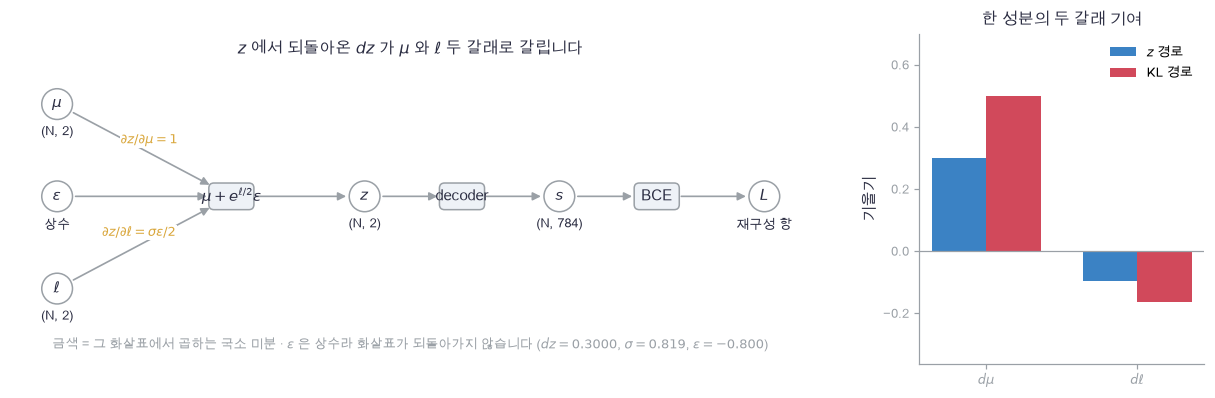

In [22]:
plot_reparam_graph(graph_dz, graph_sigma, graph_eps, (graph_dmu_path, graph_dmu_kl),
                   (graph_dlogvar_path, graph_dlogvar_kl))

🔍 **확인** · 왼쪽 그래프에서 $z$로 들어가는 화살표가 셋입니다. $\mu$에서 오는 것은 국소 미분이 1이라 $dz$가 **그대로** 지나가고, $\ell$에서 오는 것은 $\sigma\epsilon/2$를 곱해 지나갑니다. $\epsilon$에서 오는 화살표에는 금색 라벨이 없습니다. **되돌아갈 곳이 없기 때문입니다.**
오른쪽 막대에서 $d\mu$는 $z$ 경로 0.30과 KL 경로 0.50이 **같은 부호로 더해집니다**. $d\ell$은 $z$ 경로 $-0.098$과 KL 경로 $-0.165$입니다. 잡음 $\epsilon$이 음수라 $z$ 경로의 부호가 뒤집힌 것이고, $\epsilon$이 양수인 표본에서는 반대가 됩니다.
KL 경로가 $d\ell$을 음수로 미는 것은 "$\ell$을 키워라", 곧 $q$를 넓히라는 뜻입니다. $e^{\ell} < 1$이면 $\sigma$가 1보다 좁다는 뜻이고 KL은 그것을 싫어합니다.

아래 세 셀이 forward·backward·둘을 묶은 함수입니다. `vae_forward`는 캐시를 남기고, `vae_backward`는 위 식을 순서대로 옮긴 것입니다.

In [23]:
def vae_forward(X, p, eps):
    """encoder → 재매개화 → decoder 를 한 번에. 미분에 필요한 중간값을 캐시로 남깁니다.
    X: (N, D), p: 파라미터 사전, eps: (N, L) 미리 뽑은 잡음
    → (logits: (N, D), cache: (H, G, Z, mu, logvar, sigma, eps))."""
    # 쓰는 것: encoder_forward, reparameterize, decoder_forward (1절)
    mu, logvar, H = encoder_forward(X, p)
    Z, sigma = reparameterize(mu, logvar, eps)
    logits, G = decoder_forward(Z, p)
    return logits, (H, G, Z, mu, logvar, sigma, eps)

In [24]:
def vae_backward(X, p, cache, dlogits, dmu_kl, dlogvar_kl):
    """decoder backward → 재매개화에서 두 갈래로 → encoder backward. 03번 5절의 선형층 backward를 네 번 씁니다.
    X: (N, D), cache: vae_forward의 것, dlogits: (N, D), dmu_kl·dlogvar_kl: (N, L)
    → grads: 파라미터 사전과 같은 키의 기울기 사전."""
    H, G, Z, mu, logvar, sigma, eps = cache
    dpre2 = (dlogits @ p["W3"].T) * (1 - G ** 2)                      # (N, hidden): dG ⊙ tanh 도함수
    dZ = dpre2 @ p["W2"].T                                            # (N, L): 여기까지가 decoder backward
    dmu = dZ + dmu_kl                                                 # ∂z/∂μ = 1 이라 dZ가 그대로 + KL의 몫
    dlogvar = dZ * eps * sigma * 0.5 + dlogvar_kl                     # ∂z/∂ℓ = σε/2 + KL의 몫
    dpre1 = (dmu @ p["Wmu"].T + dlogvar @ p["Wlv"].T) * (1 - H ** 2)  # (N, hidden): 머리 둘에서 온 기울기의 합
    return {"W1": X.T @ dpre1, "b1": dpre1.sum(axis=0),
            "Wmu": H.T @ dmu, "bmu": dmu.sum(axis=0),
            "Wlv": H.T @ dlogvar, "blv": dlogvar.sum(axis=0),
            "W2": Z.T @ dpre2, "b2": dpre2.sum(axis=0),
            "W3": G.T @ dlogits, "b3": dlogits.sum(axis=0)}

In [25]:
def vae_gradients(X, p, eps):
    """한 배치의 forward → 손실 → backward. 학습 루프가 스텝마다 부르는 함수입니다.
    X: (N, D), p: 파라미터 사전, eps: (N, L) → (loss, recon, kl: 숫자 셋, grads: 사전)."""
    # 쓰는 것: vae_forward, vae_backward (3절) · vae_loss (2절)
    logits, cache = vae_forward(X, p, eps)
    loss, recon, kl, dlogits, dmu_kl, dlogvar_kl = vae_loss(X, logits, cache[3], cache[4])
    return loss, recon, kl, vae_backward(X, p, cache, dlogits, dmu_kl, dlogvar_kl)

📎 **참고** · 검산은 **$\epsilon$을 한 번 뽑아 고정한 채로** 합니다. 중심차분은 파라미터를 $\pm 10^{-6}$ 흔들며 손실을 두 번 재는데, 그 사이에 $\epsilon$이 새로 뽑히면 두 값이 다른 함수의 값이 되어 버립니다. 잡음이 고정된 한 이 손실은 파라미터의 보통 함수이고, 01번 3절의 중심차분이 그대로 적용됩니다.

검사는 작은 모형에서 합니다. 화소 6개, 은닉 5개, 잠재 2개, 이미지 4장입니다. 파라미터가 $10^4$개인 본 모형에서 중심차분을 돌리면 오래 걸리고, 식이 맞는지는 크기와 상관없이 판가름 나기 때문입니다.

> **코드**
>
> - `numerical_gradient(scalar, array)`: 인자 없는 함수 `scalar()`의 값을 `array`의 원소마다 $\pm\epsilon$ 흔들어 중심차분합니다(01번 3절). `array`와 같은 모양을 돌려줍니다.
> - `rel_error(a, b)`: 두 기울기의 상대오차. $10^{-6}$ 아래면 같은 값으로 봅니다.

In [26]:
# 쓰는 것: init_vae (1절) · vae_gradients, vae_forward (3절)
grad_rng = np.random.default_rng(2503)
grad_X = (grad_rng.random((4, 6)) < 0.5).astype(float)                # (4, 6): 0/1 화소 여섯 개짜리 이미지 4장
grad_p = init_vae(latent=2, hidden=5, in_dim=6, seed=77)              # 작은 모형
grad_eps = grad_rng.normal(size=(4, 2))                               # (4, 2): 검산 내내 고정할 잡음
grad_loss, _, _, grad_grads = vae_gradients(grad_X, grad_p, grad_eps)
probe_logits, probe_cache = vae_forward(grad_X, grad_p, grad_eps)     # 연습 C에서 다시 쓰는 캐시


def vae_scalar():
    """검사기용: 같은 ε을 고정한 −ELBO. 중심차분이 흔드는 것은 grad_p 안의 배열입니다."""
    return vae_gradients(grad_X, grad_p, grad_eps)[0]


grad_errors = {key: rel_error(grad_grads[key], numerical_gradient(vae_scalar, value)) for key, value in grad_p.items()}
assert max(grad_errors.values()) < 1e-6, "모든 파라미터의 상대오차가 1e−6 아래여야 합니다"
print("파라미터 10개의 최대 상대오차:", f"{max(grad_errors.values()):.2e}")
print("가장 큰 오차가 난 파라미터:", max(grad_errors, key=grad_errors.get))

파라미터 10개의 최대 상대오차: 1.97e-09
가장 큰 오차가 난 파라미터: b2


In [27]:
# 쓰는 것: grad_p, grad_X (3절 검산 셀) · vae_loss (2절) · encoder_forward (1절)
kl_mu, kl_logvar, _ = encoder_forward(grad_X, grad_p)                 # (4, 2), (4, 2)
kl_dmu = vae_loss(grad_X, np.zeros_like(grad_X), kl_mu, kl_logvar)[4]  # (4, 2): KL 쪽 dμ만 꺼냄
kl_dlogvar = vae_loss(grad_X, np.zeros_like(grad_X), kl_mu, kl_logvar)[5]


def kl_scalar():
    """검사기용: KL 항만의 배치 평균. logits를 0으로 두어 재구성 항을 상수로 만듭니다."""
    return vae_loss(grad_X, np.zeros_like(grad_X), kl_mu, kl_logvar)[2]


kl_errors = [rel_error(kl_dmu, numerical_gradient(kl_scalar, kl_mu)),
             rel_error(kl_dlogvar, numerical_gradient(kl_scalar, kl_logvar))]
assert max(kl_errors) < 1e-6, "KL 항만의 두 기울기도 상대오차가 1e−6 아래여야 합니다"
print("KL 항만의 상대오차: dμ", f"{kl_errors[0]:.2e}", "· dℓ", f"{kl_errors[1]:.2e}")

KL 항만의 상대오차: dμ 1.56e-10 · dℓ 1.72e-10


🔍 **확인** · 파라미터 10개 모두에서 손유도 기울기와 중심차분의 상대오차가 $10^{-6}$ 아래입니다. $\epsilon$을 고정했기 때문에 나온 결과이고, 검산 셀에서 `grad_eps`를 매번 새로 뽑도록 바꾸면 오차가 1 근처로 치솟습니다(바꿔 보세요).
KL 항만 따로 흔든 검산도 통과합니다. 재구성 항 없이도 $\partial \mathrm{KL}/\partial \mu = \mu / N$이 맞다는 뜻이고, 두 항의 기울기가 서로를 가려 주지 않았음을 확인한 것입니다.
**학습이 잘 되는 것은 미분이 맞다는 증거가 아닙니다.** 순서를 반대로 해, 검산을 통과한 뒤에 학습합니다.

### ✏️ 연습 3 · $\ell$ 쪽으로 갈라지는 한 줄

도착한 `dz` `(N, L)`, 고정한 잡음 `eps` `(N, L)`, `sigma` `(N, L)`에서 **재매개화가 $\ell$로 보내는 몫**을 만드는 한 줄을 채우세요. KL 쪽 기여는 더하지 않습니다. 검사는 $\sigma = (2, 4)$인 손계산과 3절 `vae_backward`가 실제로 만든 `blv` 기울기로 합니다.

In [28]:
def exercise_dlogvar_path(dz, eps, sigma):
    """연습 3: 재매개화가 ℓ로 보내는 기울기 dz ⊙ ε ⊙ σ / 2. dz·eps·sigma: 모두 (N, L) → (N, L)."""
    assert dz.shape == eps.shape == sigma.shape, "세 배열은 모두 같은 (N, L)이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dlogvar_path = dz ⊙ ε ⊙ σ / 2 (모양 (N, L))
    ### 힌트: 3절 vae_backward의 dlogvar 줄에서 KL 몫(dlogvar_kl)을 뺀 앞부분입니다. ∂z/∂ℓ = σε/2 를 dz에 곱합니다.
    raise NotImplementedError
    return dlogvar_path

In [29]:
def check_dlogvar_path(candidate):
    """σ = (2, 4)인 손계산과 3절 vae_backward가 만든 blv 기울기로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: grad_p, grad_X, grad_grads, probe_logits, probe_cache (3절 검산 셀) · vae_loss (2절)
    example_dz = np.array([[1.0, -2.0]])                             # (1, 2)
    example_eps = np.array([[1.0, 0.5]])                             # (1, 2)
    example_sigma = np.array([[2.0, 4.0]])                           # (1, 2)
    actual = candidate(example_dz, example_eps, example_sigma)
    assert actual.shape == (1, 2), f"모양은 (N, L) = (1, 2)여야 하는데 {actual.shape}입니다"
    np.testing.assert_allclose(actual, [[1.0, -2.0]])                # 검산: 손계산 1·1·2/2 = 1, (−2)·0.5·4/2 = −2
    H, G, Z, mu, logvar, sigma, eps = probe_cache
    _, _, _, dlogits, _, dlogvar_kl = vae_loss(grad_X, probe_logits, mu, logvar)
    dZ = ((dlogits @ grad_p["W3"].T) * (1 - G ** 2)) @ grad_p["W2"].T   # 3절 vae_backward와 같은 두 줄
    blv_grad = (candidate(dZ, eps, sigma) + dlogvar_kl).sum(axis=0)  # ℓ 쪽 두 몫을 더해 배치 축으로 합한 것
    np.testing.assert_allclose(blv_grad, grad_grads["blv"])          # 검산: 3절 vae_backward가 만든 blv 기울기
    print("ℓ 쪽 갈래: 손계산·vae_backward와 일치합니다.")

run_check(check_dlogvar_path, exercise_dlogvar_path, hint="dlogvar_path = dz * eps * sigma * 0.5")

☐ exercise_dlogvar_path: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dlogvar_path = dz * eps * sigma * 0.5


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dlogvar_path = dz * eps * sigma * 0.5
```

</details>

## 🔑 4. 완성 학습: MNIST 5,000장, 잠재 2차원

**이 절에서 가져갈 것:** 스텝마다 미니배치를 뽑고 **그 배치를 위한 $\epsilon$을 새로 뽑아** 한 번의 forward·backward로 두 신경망을 함께 갱신합니다. 샘플 하나로 잰 손실은 스텝마다 흔들리지만 평균이 맞아서, 재구성 항과 KL 항을 따로 기록해 두면 학습이 어디로 가는지 보입니다.

24번 5절에서 샘플 수 $K$를 늘리면 추정이 덜 흔들린다는 것을 봤습니다. VAE는 보통 $K = 1$, 곧 **표본 하나**만 씁니다.
한 스텝의 방향은 믿을 것이 못 되지만 여러 스텝에 걸쳐 잡음이 상쇄되고, 그 대신 같은 시간에 훨씬 많은 스텝을 돌 수 있기 때문입니다.
아래 셀은 같은 배치에 $\epsilon$만 바꿔 가며 $-\mathrm{ELBO}$를 12번 재 봅니다.

In [30]:
# 쓰는 것: mnist_X (📎 데이터 셀) · start_p, start_mu, start_sigma (1절 계산 셀) · vae_gradients (3절)
draw_rng = np.random.default_rng(2505)
draw_z = start_mu + start_sigma * draw_rng.normal(size=(200, 2))      # (200, 2): 같은 7에 ε을 200번 다시 뽑은 z
draw_batch = mnist_X[:32]                                             # (32, 784): 고정된 한 배치
draw_losses = [vae_gradients(draw_batch, start_p, draw_rng.normal(size=(32, 2)))[0] for _ in range(12)]
draw_mean = float(np.mean(draw_losses))
print("12번의 −ELBO 추정값:", np.array(draw_losses).round(2))
print(f"가장 작은 값 {min(draw_losses):.2f} · 가장 큰 값 {max(draw_losses):.2f} · 평균 {draw_mean:.2f}")

12번의 −ELBO 추정값: [575.71 577.95 569.98 580.16 572.29 575.71 574.35 571.83 577.62 572.71
 579.06 572.67]
가장 작은 값 569.98 · 가장 큰 값 580.16 · 평균 575.00


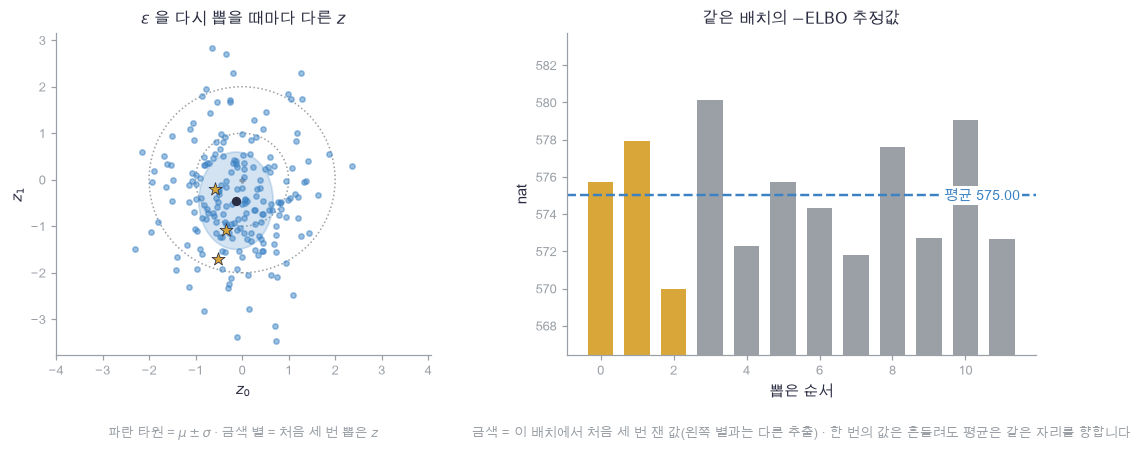

In [31]:
plot_eps_draws(start_mu[0], start_sigma[0], draw_z, np.array(draw_losses), draw_mean)

🔍 **확인** · 왼쪽에서 같은 7의 $z$가 파란 타원($\mu \pm \sigma$) 주변에 흩뿌려집니다. **encoder가 내놓는 것은 점 하나가 아니라 구름 하나**입니다. 학습 전이라 이 구름이 사전분포(점선 원)와 거의 겹쳐 있습니다.
오른쪽은 같은 배치 32장에 $\epsilon$만 바꿔 잰 $-\mathrm{ELBO}$ 열두 개입니다. 가장 작은 값과 큰 값이 10 nat 차이 나지만 평균은 한 자리에 있습니다. 학습은 이 흔들리는 값의 기울기를 그대로 씁니다.
784개 화소를 다 맞혀야 하는 문제라 값 자체가 500 nat대로 큽니다. 이 크기는 **화소 수에 비례**하므로 다른 데이터셋의 숫자와 그대로 비교하지 마세요.

아래는 04번 6절의 Adam을 파라미터 사전에 적용한 것입니다. 기울기를 모두 **같은 갱신 전 파라미터**에서 구한 뒤 함께 갱신합니다.

> **코드**
>
> - `{key: (np.zeros_like(value), np.zeros_like(value)) for key, value in p.items()}`: 파라미터마다 Adam 상태 $(m, v)$를 0으로 만든 사전.
> - `rng.integers(0, N, size=B)`: 0부터 $N-1$까지의 정수 $B$개를 복원추출로 뽑습니다. 이번 스텝의 미니배치 번호입니다(01b 2절).

In [32]:
def adam_update(p, grads, state, step, lr=2e-3):
    """Adam 갱신(04번 6절)을 파라미터 사전의 모든 배열에. p를 제자리에서 바꾸고 state의 (m, v)를 갱신합니다.
    p·grads: 같은 키의 사전, state: 키 → (m, v), step: 1부터 세는 스텝 수."""
    for key in p:
        m, v = state[key]
        m = 0.9 * m + 0.1 * grads[key]                                # 1차 모멘트
        v = 0.999 * v + 0.001 * grads[key] ** 2                       # 2차 모멘트
        p[key] -= lr * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)
        state[key] = (m, v)

In [33]:
# 쓰는 것: mnist_X (📎 데이터 셀) · init_vae (1절) · vae_gradients (3절) · adam_update (4절)
vae_p = init_vae()                                                    # 1절 계산 셀의 start_p와 같은 seed에서 출발
vae_state = {key: (np.zeros_like(value), np.zeros_like(value)) for key, value in vae_p.items()}
vae_rng = np.random.default_rng(2502)
history = {"step": [], "recon": [], "kl": []}
for step in range(3000):
    batch = vae_rng.integers(0, len(mnist_X), 100)                    # 1. 이번 스텝의 미니배치 100장
    batch_eps = vae_rng.normal(size=(100, 2))                         # 2. 이 배치만의 새 잡음
    loss, recon, kl, grads = vae_gradients(mnist_X[batch], vae_p, batch_eps)   # 3. forward → 손실 → backward
    adam_update(vae_p, grads, vae_state, step + 1)                    # 4. 두 신경망을 함께 갱신 (t는 1부터)
    if step % 50 == 0:
        history["step"].append(step)
        history["recon"].append(recon)
        history["kl"].append(kl)
assert history["recon"][-1] < history["recon"][0] * 0.4, "재구성 항이 처음의 40% 아래로 내려가야 합니다"
assert history["kl"][-1] > history["kl"][0], "KL 항은 0에서 출발해 커져야 합니다 (q가 관측마다 갈라지므로)"
print(f"재구성 항 {history['recon'][0]:.1f} → {history['recon'][-1]:.1f} nat")
print(f"KL 항 {history['kl'][0]:.2f} → {history['kl'][-1]:.2f} nat · 합 {history['recon'][-1] + history['kl'][-1]:.1f} nat")

재구성 항 575.5 → 155.3 nat
KL 항 0.25 → 6.10 nat · 합 161.4 nat


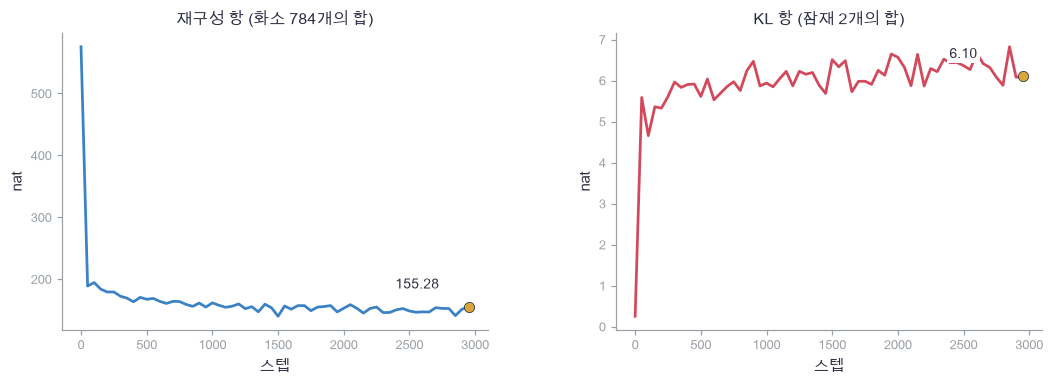

In [34]:
plot_loss_history(history["step"], history["recon"], history["kl"])

🔍 **확인** · 재구성 항이 첫 스텝의 575 nat에서 155 nat 부근까지 내려갑니다. 선이 매끄럽지 않고 잘게 떨리는 것은 스텝마다 배치도 $\epsilon$도 새로 뽑히기 때문입니다.
KL 항은 반대로 **0에서 출발해 올라갑니다.** 학습 전에는 모든 이미지의 $q$가 사전분포와 거의 같아서 KL이 0에 가깝고, 학습이 진행되면 이미지마다 $q$가 서로 다른 자리로 갈라지면서 사전분포에서 멀어집니다. 그 대가로 재구성이 좋아지는 절충입니다.
두 항의 크기 차이(155 대 6)를 눈여겨 보세요. 화소 784개의 합과 잠재 2개의 합이라 저울이 심하게 기울어 있습니다. 26번에서 KL 항에 $\beta$를 곱해 이 저울을 조정합니다.

이제 학습된 모형으로 고정 예시 10장을 복원해 봅니다. 여기서는 $\epsilon$을 뽑지 않고 $\mu$를 그대로 decoder에 넣습니다(구름의 가운데를 쓰는 것입니다).

In [35]:
# 쓰는 것: mnist_flat, mnist_labels (📎 데이터 셀) · encoder_forward, decoder_forward (1절) · sigmoid (📎 02번 함수 셀) · vae_p (4절 학습 셀)
example_mu, example_logvar, _ = encoder_forward(mnist_flat, vae_p)    # (10, 2), (10, 2)
example_prob = sigmoid(decoder_forward(example_mu, vae_p)[0])         # (10, 784): μ만 넣은 복원 확률
example_recon = example_prob.reshape(10, 28, 28)
example_error = np.abs(example_prob - mnist_flat).mean(axis=1)        # (10,): 이미지마다 화소 평균 절대오차
print("복원의 화소 평균 절대오차:", example_error.round(3))
print("가장 잘 복원된 숫자", int(mnist_labels[example_error.argmin()]), "· 가장 못한 숫자", int(mnist_labels[example_error.argmax()]))

복원의 화소 평균 절대오차: [0.083 0.03  0.129 0.102 0.123 0.121 0.103 0.071 0.084 0.089]
가장 잘 복원된 숫자 1 · 가장 못한 숫자 2


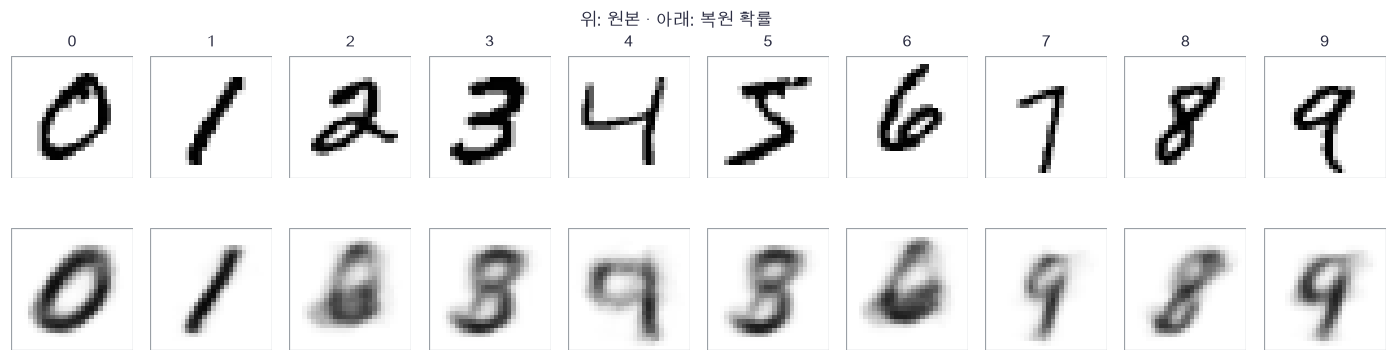

In [36]:
plot_recon_pairs(mnist_examples, example_recon, mnist_labels)

🔍 **확인** · 0·1·8·9는 알아볼 수 있게 돌아옵니다. 반면 4와 7은 9로, 5는 3으로, 2는 6으로 **다른 숫자가 되어** 나옵니다. **잠재가 2차원뿐**이라 열 가지 숫자를 평면 하나에 다 펼칠 수 없기 때문입니다. 노트북 끝의 완성 예제에서 잠재를 8차원으로 늘려 이 그림이 어떻게 달라지는지 봅니다.
복원이 전체적으로 흐린 것은 Bernoulli 확률을 그대로 그렸기 때문이기도 합니다. 각 화소의 확률이 0이나 1이 아니라 중간값이면 회색으로 보입니다.

다음은 잠재 평면 자체를 봅니다. 왼쪽은 격자 위의 $z$를 decoder에 넣어 얻은 그림이고, 오른쪽은 학습 데이터 5,000장의 $\mu$입니다.

> **코드**
>
> - `np.quantile(values, 0.02)`: 값들을 정렬했을 때 아래에서 2% 자리의 값. $\mu$가 실제로 놓인 구간을 격자로 쓰기 위한 것입니다.
> - `np.block([[...] for ...])`: 작은 배열들을 격자로 이어 붙여 큰 배열 하나로 만듭니다. 여기서는 28×28 그림 64장을 224×224 한 장으로.

In [37]:
# 쓰는 것: mnist_X (📎 데이터 셀) · encoder_forward, decoder_forward (1절) · sigmoid (📎 02번 함수 셀) · vae_p (4절 학습 셀)
latent_mu, latent_logvar, _ = encoder_forward(mnist_X, vae_p)         # (5000, 2): 학습 데이터의 q 평균
grid_x = np.linspace(np.quantile(latent_mu[:, 0], 0.02), np.quantile(latent_mu[:, 0], 0.98), 8)
grid_y = np.linspace(np.quantile(latent_mu[:, 1], 0.02), np.quantile(latent_mu[:, 1], 0.98), 8)
grid_z = np.array([[a, b] for b in grid_y[::-1] for a in grid_x])     # (64, 2): 위에서 아래로 읽는 순서
grid_images = sigmoid(decoder_forward(grid_z, vae_p)[0]).reshape(8, 8, 28, 28)
grid_tiled = np.block([[grid_images[i, j] for j in range(8)] for i in range(8)])   # (224, 224)
print("μ의 평균", latent_mu.mean(axis=0).round(2), "· 표준편차", latent_mu.std(axis=0).round(2))
print("σ의 평균", np.exp(0.5 * latent_logvar).mean(axis=0).round(3), "(사전분포는 1)")

μ의 평균 [ 0.62 -0.83] · 표준편차 [1.35 1.21]
σ의 평균 [0.095 0.081] (사전분포는 1)


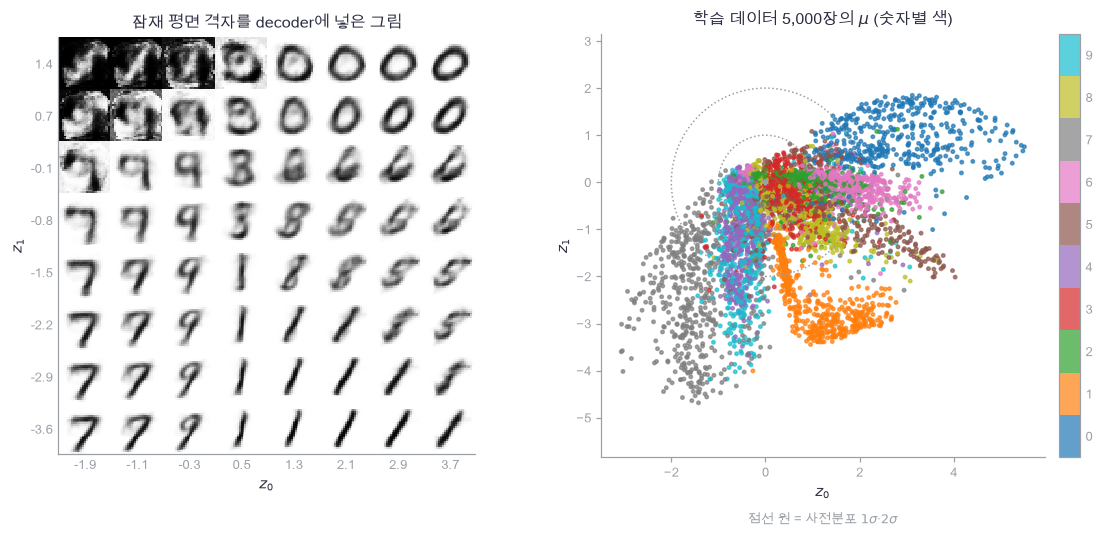

In [38]:
plot_latent_map(grid_tiled, grid_x, grid_y, latent_mu, mnist_y)

🔍 **확인** · 왼쪽 판을 가로세로로 훑으면 숫자가 **조금씩 변형**됩니다. 이웃한 칸끼리 비슷한 것은 decoder가 연속 함수라 그렇습니다. 오른쪽 위 구석은 0, 왼쪽 아래는 7, 오른쪽 아래는 1입니다.
왼쪽 위 몇 칸은 검게 뭉개져 있습니다. 오른쪽 산점을 보면 그 자리에는 $\mu$가 거의 가지 않습니다. **decoder가 학습 중에 본 적 없는 입력**이라 아무 값이나 내놓는 것입니다.
오른쪽에서 $\mu$의 표준편차가 1보다 크고 중심도 원점에서 밀려 있습니다. 사전분포(점선 원)와 딱 맞지 않는다는 뜻이고, 재구성 항이 KL 항보다 훨씬 무겁기 때문입니다. 5절에서 사전분포에서 뽑아 그림을 만들 때 이 어긋남이 그대로 드러납니다.
색은 숫자별로 다르지만 **학습에는 라벨을 전혀 쓰지 않았습니다.** 그런데도 같은 숫자끼리 뭉쳐 있습니다.

### 🔍 진짜 밀도를 아는 데이터에서: 하한이 정말 하한인가

MNIST에서는 $\log p(x)$의 참값을 모르니 "하한이 얼마나 낮은가"를 잴 수 없습니다. 23번의 **2차원 두 봉우리 혼합**은 밀도를 손으로 쓸 수 있는 데이터라 그 비교가 됩니다.
같은 VAE를 관측 모형만 Gaussian으로 바꿔 씁니다. $p(x \mid z) = \mathcal{N}(m(z),\ s^2 I)$에서 $m(z)$는 decoder가 내는 2차원 평균이고 $s = 0.5$로 고정합니다. 잠재는 **1차원**입니다.
재구성 항은 Gaussian의 음의 로그 밀도가 되어 $\sum_d\big[\tfrac12\log(2\pi s^2) + (x_d - m_d)^2/(2s^2)\big]$이고, 기울기는 $\partial/\partial m = (m - x)/s^2$입니다. KL 항과 backward는 **하나도 바뀌지 않습니다.**

두 가지를 비교합니다. 학습한 하한의 평균 $\frac1N\sum_n \mathrm{ELBO}(x_n)$과, 진짜 밀도의 평균 $\frac1N\sum_n \log p_{\text{혼합}}(x_n)$입니다. 두 번째 값은 데이터 분포의 **음의 entropy**를 몬테카를로로 잰 것이기도 합니다.
부등식은 두 단계로 겹칩니다. 하한은 모델의 $\log p_\theta(x)$를 넘지 못하고(24번 2절), 모델의 평균 $\log p_\theta$는 진짜 분포의 평균 $\log p$를 넘지 못합니다(그 차이가 $D_{KL}(p_{\text{데이터}}\,\|\,p_\theta) \geq 0$).

In [39]:
MIX2_PI = np.array([0.4, 0.6])                                        # (2,): 성분 비율 (23번과 같은 값)
MIX2_MU = np.array([[-2.0, 0.0], [2.0, 1.0]])                         # (2, 2): 성분 평균
MIX2_COV = np.array([[[0.6, 0.2], [0.2, 0.5]],                        # (2, 2, 2): 성분 공분산
                     [[0.4, -0.1], [-0.1, 0.8]]])
MIX_SIGMA_OBS = 0.5                                                   # Gaussian 관측 모형의 고정 잡음 s
print("혼합 π", MIX2_PI, "· 성분 평균", MIX2_MU.tolist(), "· 관측 잡음 s =", MIX_SIGMA_OBS)

혼합 π [0.4 0.6] · 성분 평균 [[-2.0, 0.0], [2.0, 1.0]] · 관측 잡음 s = 0.5


In [40]:
def mix2_logpdf(X):
    """2차원 두 봉우리 혼합의 로그 밀도 (23번 1절). 성분 로그 항을 만들고 행마다 logsumexp.
    X: (N, 2) → (N,)."""
    # 쓰는 것: MIX2_PI, MIX2_MU, MIX2_COV (4절 혼합 상수 셀)
    terms = []
    for k in range(len(MIX2_PI)):
        centered = X - MIX2_MU[k]                                     # (N, 2)
        quadratic = np.sum(centered @ np.linalg.inv(MIX2_COV[k]) * centered, axis=1)   # (N,): (x−μ)ᵀ Σ⁻¹ (x−μ)
        normalizer = np.log((2 * np.pi) ** 2 * np.linalg.det(MIX2_COV[k]))
        terms.append(np.log(MIX2_PI[k]) - 0.5 * (normalizer + quadratic))
    stacked = np.stack(terms, axis=1)                                 # (N, 2): 성분별 log π_k + log N
    biggest = stacked.max(axis=1, keepdims=True)                      # 최댓값을 빼고 더해 넘침을 막습니다
    return (biggest + np.log(np.exp(stacked - biggest).sum(axis=1, keepdims=True)))[:, 0]

In [41]:
def mix2_sample(n, rng):
    """혼합에서 n개 뽑기 (23번 5절): 성분을 π로 고른 뒤 그 성분의 Gaussian에서 뽑습니다.
    n: 개수, rng: 난수 생성기 → (n, 2)."""
    # 쓰는 것: MIX2_PI, MIX2_MU, MIX2_COV (4절 혼합 상수 셀)
    which = rng.choice(len(MIX2_PI), size=n, p=MIX2_PI)               # (n,): 성분 번호
    out = np.empty((n, 2))
    for k in range(len(MIX2_PI)):
        chosen = which == k
        lower = np.linalg.cholesky(MIX2_COV[k])                       # Σ = L Lᵀ 이면 μ + ε L ᵀ 가 그 성분의 표본 (12번 1절)
        out[chosen] = MIX2_MU[k] + rng.normal(size=(int(chosen.sum()), 2)) @ lower.T
    return out

In [42]:
def gauss_loss(X, out, mu, logvar):
    """관측 모형만 Gaussian으로 바꾼 −ELBO와 기울기. 재구성 항은 ½log(2πs²) + (x−m)²/(2s²), KL은 그대로.
    X·out: (N, 2), mu·logvar: (N, L) → vae_loss와 같은 순서의 6개."""
    # 쓰는 것: MIX_SIGMA_OBS (4절 혼합 상수 셀)
    N = len(X)
    variance = MIX_SIGMA_OBS ** 2
    recon = float(np.sum(0.5 * np.log(2 * np.pi * variance) + (X - out) ** 2 / (2 * variance)) / N)
    kl = float(0.5 * np.sum(mu ** 2 + np.exp(logvar) - 1.0 - logvar) / N)
    return recon + kl, recon, kl, (out - X) / variance / N, mu / N, 0.5 * (np.exp(logvar) - 1.0) / N

In [43]:
# 쓰는 것: init_vae (1절) · vae_forward, vae_backward (3절) · adam_update (4절) · mix2_sample, gauss_loss (4절 🔍 소절)
mix_rng = np.random.default_rng(2510)
mix_X = mix2_sample(2000, mix_rng)                                    # (2000, 2): 혼합에서 뽑은 학습 데이터
mix_p = init_vae(latent=1, hidden=32, in_dim=2, seed=2511)
mix_state = {key: (np.zeros_like(value), np.zeros_like(value)) for key, value in mix_p.items()}
mix_train_rng = np.random.default_rng(2512)
for step in range(1500):
    batch = mix_train_rng.integers(0, len(mix_X), 128)
    batch_eps = mix_train_rng.normal(size=(128, 1))
    out, cache = vae_forward(mix_X[batch], mix_p, batch_eps)          # decoder의 출력을 logit이 아니라 평균으로 읽습니다
    _, _, _, dout, dmu_kl, dlogvar_kl = gauss_loss(mix_X[batch], out, cache[3], cache[4])
    adam_update(mix_p, vae_backward(mix_X[batch], mix_p, cache, dout, dmu_kl, dlogvar_kl), mix_state, step + 1, lr=5e-3)
print("혼합 VAE 학습 완료 · 파라미터 수", sum(value.size for value in mix_p.values()))

혼합 VAE 학습 완료 · 파라미터 수 292


In [44]:
# 쓰는 것: mix_X, mix_p (4절 🔍 소절 학습 셀) · mix2_logpdf, gauss_loss (4절 🔍 소절) · vae_forward, decoder_forward (1·3절) · MIX_SIGMA_OBS (4절 혼합 상수 셀)
eval_rng = np.random.default_rng(2513)
mix_out, mix_cache = vae_forward(mix_X, mix_p, eval_rng.normal(size=(len(mix_X), 1)))
_, mix_recon, mix_kl, _, _, _ = gauss_loss(mix_X, mix_out, mix_cache[3], mix_cache[4])
mix_elbo = -(mix_recon + mix_kl)                                      # ELBO = −(재구성 + KL)
mix_true = float(np.mean(mix2_logpdf(mix_X)))                         # 진짜 밀도의 평균 log p(x) (음의 entropy)
mix_line = np.linspace(-2.6, 2.6, 200)[:, None]                       # (200, 1): 잠재 축 위의 격자
mix_curve = decoder_forward(mix_line, mix_p)[0]                       # (200, 2): decoder가 그리는 곡선 m(z)
mix_samples = decoder_forward(eval_rng.normal(size=(600, 1)), mix_p)[0] + MIX_SIGMA_OBS * eval_rng.normal(size=(600, 2))
assert mix_elbo < mix_true, "학습한 하한은 진짜 평균 log 밀도보다 작아야 합니다"
print(f"ELBO 평균 {mix_elbo:.4f} · 진짜 log p(x) 평균 {mix_true:.4f} · 모자란 양 {mix_true - mix_elbo:.4f} nat")

ELBO 평균 -3.0823 · 진짜 log p(x) 평균 -2.8674 · 모자란 양 0.2149 nat


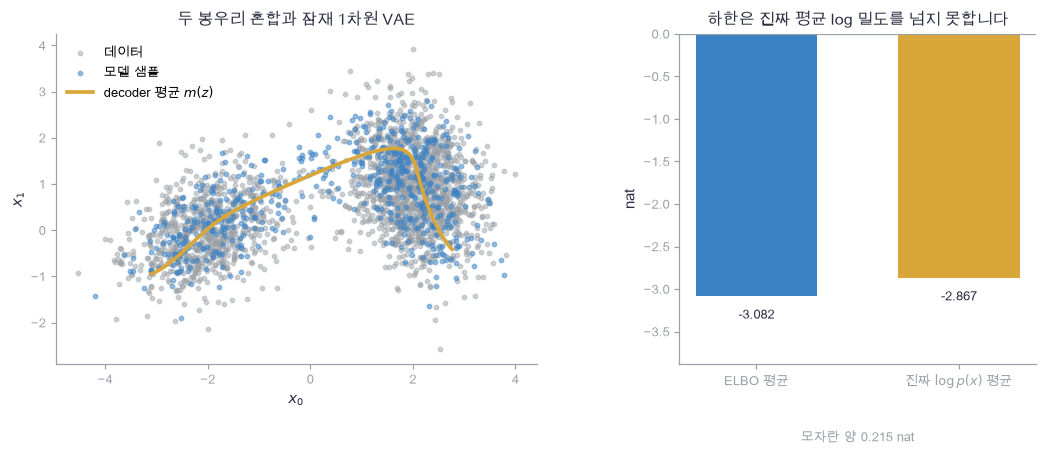

In [45]:
plot_mixture_vae(mix_X, mix_samples, mix_curve, mix_elbo, mix_true)

🔍 **확인** · 왼쪽에서 금색 곡선이 decoder가 그리는 $m(z)$입니다. 잠재가 **1차원**이라 decoder가 그릴 수 있는 것은 평면 위의 **곡선 하나**뿐이고, 관측 잡음 $s = 0.5$가 그 곡선을 두툼하게 만들어 두 봉우리를 덮습니다. 파란 모델 샘플이 회색 데이터와 상당히 겹칩니다.
오른쪽에서 하한이 $-3.08$, 진짜 평균 $\log p(x)$가 $-2.87$입니다. **하한이 아래에 있습니다.** 모자란 0.21 nat 안에는 두 가지가 섞여 있습니다. $q$가 정확한 posterior가 아니라서 생긴 몫(24번 2절)과, 모델 자체가 진짜 분포와 달라서 생긴 몫입니다.
잠재를 2차원으로 늘리거나 $s$를 학습 대상으로 두면 이 값이 더 올라갑니다. 지금은 두 가지만 확인하면 됩니다. **부등식이 실제 숫자로 지켜지고, 관측 모형을 바꿔도 KL 항과 backward는 그대로**라는 것입니다.

### ✏️ 연습 4 · 사전 하나로 두 신경망을 함께 갱신하기

파라미터 사전 `p`와 같은 키의 기울기 사전 `grads`, 학습률 `lr`에서 **새 사전** `updated`를 만드는 한 줄을 채우세요. 반복문은 써 두었습니다. encoder와 decoder가 같은 사전 안에 있으므로 이 한 줄이 두 신경망을 함께 갱신합니다. 검사는 손계산과 1절 `init_vae`의 키 10개로 합니다.

In [46]:
def exercise_sgd_step(p, grads, lr):
    """연습 4: 사전의 모든 파라미터를 경사하강 한 스텝 갱신한 새 사전. p·grads: 같은 키의 사전, lr: 숫자 → 새 사전."""
    assert set(p) == set(grads), "p와 grads의 키가 같아야 합니다"
    updated = {}
    for key in p:
        ### 이 주석 아래에 다음을 구현하세요.
        ### 구현할 내용: updated[key] = 이 파라미터에서 lr × 기울기를 뺀 배열
        ### 힌트: 4절 adam_update의 마지막 갱신 줄에서 Adam의 보정을 뺀 가장 단순한 형태입니다(01번 6절).
        raise NotImplementedError
    return updated

In [47]:
def check_sgd_step(candidate):
    """손계산 두 배열과 1절 init_vae의 키 10개로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: init_vae (1절)
    example_p = {"W1": np.array([[1.0, 2.0]]), "b1": np.array([0.5])}
    example_grads = {"W1": np.array([[0.5, -1.0]]), "b1": np.array([2.0])}
    actual = candidate(example_p, example_grads, 0.1)
    assert set(actual) == {"W1", "b1"}, f"돌려주는 사전의 키가 원래와 같아야 하는데 {sorted(actual)}입니다"
    np.testing.assert_allclose(actual["W1"], [[0.95, 2.1]])           # 검산: 손계산 1 − 0.1·0.5, 2 − 0.1·(−1)
    np.testing.assert_allclose(actual["b1"], [0.3])                   # 검산: 0.5 − 0.1·2
    np.testing.assert_allclose(example_p["W1"], [[1.0, 2.0]])         # 검산: 원래 사전은 그대로 (새 사전을 만들어야 합니다)
    small_p = init_vae(latent=2, hidden=4, in_dim=3, seed=5)
    small_grads = {key: np.ones_like(value) for key, value in small_p.items()}
    stepped = candidate(small_p, small_grads, 1.0)
    assert len(stepped) == 10, f"encoder와 decoder를 합쳐 파라미터가 10개여야 하는데 {len(stepped)}개입니다"
    np.testing.assert_allclose(stepped["b3"], small_p["b3"] - 1.0)    # 검산: decoder의 마지막 편향도 같은 규칙으로
    print("두 신경망 함께 갱신: 손계산·init_vae의 키 10개와 일치합니다.")

run_check(check_sgd_step, exercise_sgd_step, hint="updated[key] = p[key] - lr * grads[key]")

☐ exercise_sgd_step: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: updated[key] = p[key] - lr * grads[key]


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
updated[key] = p[key] - lr * grads[key]
```

</details>

## 🔑 5. 사용: 복원·생성·보간은 모두 같은 decoder 하나

**이 절에서 가져갈 것:** 학습이 끝나면 쓸 일이 셋입니다. **복원**은 $x \to \mu \to$ decoder, **생성**은 사전분포에서 뽑은 $z \to$ decoder, **보간**은 두 잠재점 사이의 직선 위 $z \to$ decoder입니다. 셋 다 decoder는 그대로이고 **$z$를 어디서 가져오느냐만 다릅니다.**

학습 중에는 $z$를 encoder가 만든 $q(z \mid x)$에서 뽑았습니다. 학습이 끝나면 encoder 없이도 됩니다.
모델이 주장하는 이야기는 "$z \sim \mathcal{N}(0, I)$을 뽑고 decoder에 넣으면 그럴듯한 숫자가 나온다"이기 때문입니다.

$$\text{복원: } z = \mu(x), \qquad \text{생성: } z \sim \mathcal{N}(0, I), \qquad
\text{보간: } z(t) = (1 - t)\,z_A + t\,z_B,\ \ t \in [0, 1].$$

보간에서 $t$를 0에서 1까지 8단계로 나누면 $z$는 $(8, 2)$가 되고, decoder를 지나 $(8, 784)$ 그림 여덟 장이 됩니다.
아래 셀은 학습된 `vae_p`로 세 가지를 모두 NumPy로 직접 계산합니다.

> **코드**
>
> - `np.linspace(0.0, 1.0, 8)[:, None]`: 0부터 1까지 8개를 만든 뒤 `(8, 1)`로 세웁니다. `(2,)`짜리 잠재점과 브로드캐스팅하면 `(8, 2)`가 됩니다(00b 3절).

In [48]:
# 쓰는 것: decoder_forward (1절) · sigmoid (📎 02번 함수 셀) · vae_p (4절 학습 셀) · example_mu (4절 복원 셀)
use_rng = np.random.default_rng(2507)
use_prior_z = use_rng.normal(size=(8, 2))                             # (8, 2): 사전분포 N(0, I)에서 뽑은 잠재
use_prior = sigmoid(decoder_forward(use_prior_z, vae_p)[0]).reshape(8, 28, 28)
use_weights = np.linspace(0.0, 1.0, 8)[:, None]                       # (8, 1): 보간 가중치 t
use_path_z = (1 - use_weights) * example_mu[7] + use_weights * example_mu[1]   # (8, 2): 7의 μ에서 1의 μ로
use_path = sigmoid(decoder_forward(use_path_z, vae_p)[0]).reshape(8, 28, 28)
print("prior 샘플의 잉크 평균", use_prior.mean(axis=(1, 2)).round(3))
print("보간 양 끝의 z:", use_path_z[0].round(3), "→", use_path_z[-1].round(3))

prior 샘플의 잉크 평균 [0.149 0.104 0.721 0.147 0.121 0.335 0.626 0.162]
보간 양 끝의 z: [-0.097 -1.601] → [ 1.895 -2.789]


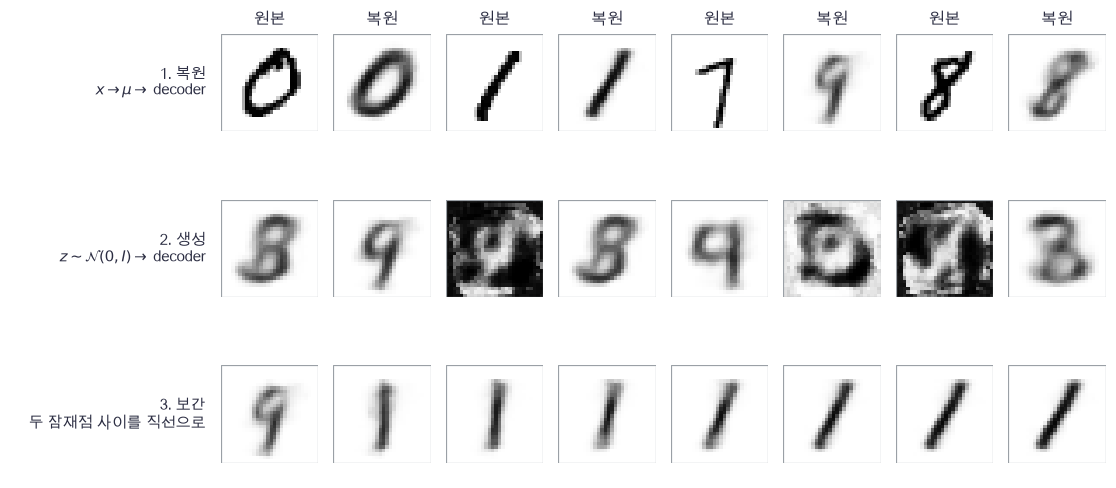

In [49]:
plot_vae_uses(mnist_examples[[0, 1, 7, 8]], example_recon[[0, 1, 7, 8]], use_prior, use_path)

🔍 **확인** · 첫 줄은 4절에서 본 복원입니다. 둘째 줄은 **원본 없이** 사전분포에서 뽑은 $z$만으로 그린 것입니다. 숫자처럼 보이는 것도 있고, 잉크가 뒤집힌 듯한 판도 있습니다.
그 판들은 $z$가 4절 산점에서 $\mu$가 거의 가지 않는 자리에 떨어져서 생깁니다. **사전분포와 실제 $\mu$ 분포가 어긋나 있다**는 것을 눈으로 본 셈입니다. 위의 `use_prior` 잉크 평균에서도 그 판들만 값이 크게 나옵니다.
셋째 줄이 보간입니다. 출발점이 9처럼 보이는 것은 4절에서 본 7의 복원이 원래 그렇기 때문입니다. 1의 $\mu$로 곧게 가는 동안 그림이 **끊기지 않고** 변합니다. 잠재 공간에서 가까운 두 점이 비슷한 그림을 낸다는 뜻이고, 화소 공간에서 두 이미지를 그냥 평균내면(두 그림이 겹쳐 보이는) 이런 결과가 나오지 않습니다.

아래는 이 세 가지를 함수로 묶은 것입니다.

In [50]:
def vae_reconstruct(X, p):
    """복원: encoder의 μ를 그대로 decoder에 넣습니다(샘플을 뽑지 않아 매번 같은 결과).
    X: (N, D), p: 파라미터 사전 → (N, D) 화소 확률."""
    # 쓰는 것: encoder_forward, decoder_forward (1절) · sigmoid (📎 02번 함수 셀)
    mu, _, _ = encoder_forward(X, p)
    return sigmoid(decoder_forward(mu, p)[0])


def vae_generate(p, n, rng):
    """생성: 사전분포 N(0, I)에서 z를 n개 뽑아 decoder에 넣습니다.
    p: 파라미터 사전, n: 개수, rng: 난수 생성기 → (z: (n, L), prob: (n, D))."""
    z = rng.normal(size=(n, p["Wmu"].shape[1]))                       # 잠재 차원 L은 Wmu의 열 수
    return z, sigmoid(decoder_forward(z, p)[0])

In [51]:
def latent_interpolate(z_start, z_end, steps):
    """보간: 두 잠재점을 곧게 잇는 z. z(t) = (1−t) z_start + t z_end, t는 0부터 1까지 균등.
    z_start·z_end: (L,), steps: 개수 → (steps, L)."""
    weights = np.linspace(0.0, 1.0, steps)[:, None]                   # (steps, 1): 세워서 브로드캐스팅
    return (1 - weights) * z_start + weights * z_end

In [52]:
# 쓰는 것: mnist_flat (📎 데이터 셀) · vae_p (4절 학습 셀) · example_mu, example_recon (4절 복원 셀) · use_path_z (5절 계산 셀)
np.testing.assert_allclose(vae_reconstruct(mnist_flat, vae_p).reshape(10, 28, 28), example_recon)   # 검산: 위 계산 셀의 복원과 같음
np.testing.assert_allclose(latent_interpolate(example_mu[7], example_mu[1], 8), use_path_z)         # 검산: 위 계산 셀의 보간과 같음
np.testing.assert_allclose(latent_interpolate(example_mu[7], example_mu[1], 8)[0], example_mu[7])   # 검산: t = 0이면 정확히 출발점
np.testing.assert_allclose(latent_interpolate(example_mu[7], example_mu[1], 8)[-1], example_mu[1])  # 검산: t = 1이면 정확히 도착점
sample_z, sample_prob = vae_generate(vae_p, 4000, np.random.default_rng(99))
assert sample_prob.shape == (4000, 784), "생성 결과는 이미지마다 화소 784개여야 합니다"
assert np.all((sample_prob > 0) & (sample_prob < 1)), "화소 확률은 0과 1 사이여야 합니다"
np.testing.assert_allclose(sample_z.mean(axis=0), [0.0, 0.0], atol=0.05)   # 검산: 사전분포에서 뽑았으니 평균 0
np.testing.assert_allclose(sample_z.std(axis=0), [1.0, 1.0], atol=0.05)    # 검산: 표준편차 1
print("생성 4,000장 · z의 평균", sample_z.mean(axis=0).round(4), "· 표준편차", sample_z.std(axis=0).round(4))

생성 4,000장 · z의 평균 [ 0.0287 -0.0168] · 표준편차 [0.9853 0.9872]


📎 **참고** · 5절에서 본 어긋남(사전분포에서 뽑으면 이상한 그림이 섞임)은 VAE를 쓰다 보면 반드시 만나는 문제이고, 26번에서 이름을 붙여 다룹니다.

- **$\beta$-VAE**: KL 항에 계수 $\beta$를 곱해 두 항의 저울을 조정합니다. $\beta$를 키우면 $q$가 사전분포에 가까워져 생성이 안정되지만 복원이 흐려집니다.
- **posterior collapse**: $\beta$가 너무 크거나 decoder가 너무 강하면 KL이 0으로 내려앉아 $q(z \mid x)$가 $x$와 무관해집니다. 잠재가 아무 일도 하지 않게 되는 상태입니다. 24번 완성 예제의 "$a^2/s^2$가 작으면 posterior가 사전분포로 돌아간다"가 이것의 작은 판이었습니다.
- 26번은 설계만 다루므로 이 노트북의 코드를 그대로 이어서 읽으면 됩니다.

### ✏️ 연습 5 · 두 잠재점 사이를 곧게 잇기

잠재점 두 개 `z_start` `(L,)`, `z_end` `(L,)`와 단계 수 `steps`에서 보간 잠재 `Z` `(steps, L)`를 만드는 한 줄을 채우세요. 가중치 `weights` `(steps, 1)`는 만들어 두었습니다. 검사는 손계산 다섯 단계와 5절 `latent_interpolate`로 합니다.

In [53]:
def exercise_interpolate(z_start, z_end, steps):
    """연습 5: 두 잠재점을 곧게 잇는 z. z_start·z_end: (L,), steps: 개수 → (steps, L)."""
    assert z_start.shape == z_end.shape, "두 잠재점은 같은 (L,)이어야 합니다"
    weights = np.linspace(0.0, 1.0, steps)[:, None]                   # (steps, 1): t를 세워 둔 것
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: Z = (1 − t)·z_start + t·z_end (모양 (steps, L))
    ### 힌트: 5절 latent_interpolate의 한 줄입니다. (steps, 1)과 (L,)이 브로드캐스팅되어 (steps, L)이 됩니다.
    raise NotImplementedError
    return Z

In [54]:
def check_interpolate(candidate):
    """다섯 단계 손계산과 5절 latent_interpolate로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: latent_interpolate (5절) · example_mu (4절 복원 셀)
    actual = candidate(np.array([0.0, 0.0]), np.array([2.0, -4.0]), 5)
    assert actual.shape == (5, 2), f"모양은 (steps, L) = (5, 2)여야 하는데 {actual.shape}입니다"
    np.testing.assert_allclose(actual, [[0.0, 0.0], [0.5, -1.0], [1.0, -2.0], [1.5, -3.0], [2.0, -4.0]])   # 검산: 손계산 다섯 단계
    reference = latent_interpolate(example_mu[7], example_mu[1], 8)
    np.testing.assert_allclose(candidate(example_mu[7], example_mu[1], 8), reference)   # 검산: 5절 latent_interpolate
    print("보간 잠재: 손계산·latent_interpolate와 일치합니다.")

run_check(check_interpolate, exercise_interpolate, hint="Z = (1 - weights) * z_start + weights * z_end")

☐ exercise_interpolate: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: Z = (1 - weights) * z_start + weights * z_end


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
Z = (1 - weights) * z_start + weights * z_end
```

</details>

## ✏️ 6. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 대각 KL과 그 기울기 두 개 (2·3절)

절 연습 2·3은 재구성 항과 $\ell$ 갈래를 따로 물었습니다. 이번에는 KL 항 하나에서 **값과 기울기 두 개를 한꺼번에** 만듭니다. 배치 평균은 하지 않고 전부 더한 값을 돌려주세요.

In [55]:
def exercise_diag_kl(mu, logvar):
    """연습 A: KL(N(μ, e^ℓ) ‖ N(0, I))와 그 기울기 (12번 5절). mu·logvar: (N, L) → (kl: 숫자, dmu: (N, L), dlogvar: (N, L))."""
    assert mu.shape == logvar.shape, "mu와 logvar는 같은 (N, L)이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: kl = ½ Σ(μ² + e^ℓ − 1 − ℓ) (전부 더한 숫자 하나), dmu = μ, dlogvar = ½(e^ℓ − 1)
    ### 힌트: 2절 vae_loss의 kl·dmu_kl·dlogvar_kl 세 줄에서 배치 평균 1/N만 뺀 것입니다.
    raise NotImplementedError
    return kl, dmu, dlogvar

In [56]:
def check_diag_kl(candidate):
    """σ = (1, 2)인 손계산과 중심차분, 그리고 2절 vae_loss로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: vae_loss (2절) · numerical_gradient, rel_error (준비 셀)
    example_mu = np.array([[1.0, 0.0]])                              # (1, 2)
    example_logvar = np.array([[0.0, np.log(4.0)]])                  # (1, 2): e^ℓ = (1, 4)
    kl, dmu, dlogvar = candidate(example_mu, example_logvar)
    np.testing.assert_allclose(kl, 1.30685282)                       # 검산: 손계산 ½[(1+1−1−0) + (0+4−1−1.3862944)]
    np.testing.assert_allclose(dmu, [[1.0, 0.0]])                    # 검산: ∂KL/∂μ = μ
    np.testing.assert_allclose(dlogvar, [[0.0, 1.5]])                # 검산: ½(e^ℓ − 1) = (0, 1.5)
    probe_mu = np.array([[0.4, -0.7]])
    probe_logvar = np.array([[-0.3, 0.6]])

    def kl_only():
        """검사기용: 후보가 돌려주는 KL 값(중심차분할 대상)."""
        return float(candidate(probe_mu, probe_logvar)[0])

    _, probe_dmu, probe_dlogvar = candidate(probe_mu, probe_logvar)
    assert rel_error(probe_dmu, numerical_gradient(kl_only, probe_mu)) < 1e-6, "dmu가 중심차분과 1e−6 안에서 같아야 합니다"
    assert rel_error(probe_dlogvar, numerical_gradient(kl_only, probe_logvar)) < 1e-6, "dlogvar가 중심차분과 1e−6 안에서 같아야 합니다"
    reference = vae_loss(np.zeros((1, 2)), np.zeros((1, 2)), probe_mu, probe_logvar)[2]
    np.testing.assert_allclose(candidate(probe_mu, probe_logvar)[0], reference)   # 검산: 2절 vae_loss의 kl (N = 1)
    print("대각 KL과 기울기: 손계산·중심차분·vae_loss와 일치합니다.")

run_check(check_diag_kl, exercise_diag_kl, hint="kl = 0.5 * np.sum(mu ** 2 + np.exp(logvar) - 1.0 - logvar) · dmu = mu · dlogvar = 0.5 * (np.exp(logvar) - 1.0)")

☐ exercise_diag_kl: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: kl = 0.5 * np.sum(mu ** 2 + np.exp(logvar) - 1.0 - logvar) · dmu = mu · dlogvar = 0.5 * (np.exp(logvar) - 1.0)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
kl = float(0.5 * np.sum(mu ** 2 + np.exp(logvar) - 1.0 - logvar))
dmu = mu
dlogvar = 0.5 * (np.exp(logvar) - 1.0)
```

</details>

### ✏️ 연습 B · 확률로 쓴 Bernoulli 재구성 항 (2절)

절 연습 2는 logit으로 쓴 안정된 형태를 물었습니다. 이번에는 02번 7절의 **확률 형태**로, 배치 평균 없이 **이미지마다 하나씩** 돌려줍니다. 두 식이 같은 값이라는 것을 눈으로 확인하는 문제입니다.

In [57]:
def exercise_bernoulli_recon(X, prob):
    """연습 B: 이미지별 재구성 항 −Σ_화소 [x log p + (1−x) log(1−p)] (02번 7절). X·prob: (N, D) → (N,)."""
    assert X.shape == prob.shape, "X와 prob은 같은 (N, D)여야 합니다"
    assert np.all((prob > 0) & (prob < 1)), "이 연습은 0과 1 사이의 확률만 다룹니다 (로그가 발산하지 않게)"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: recon = 화소 축(axis=1)만 더한 −[x log p + (1−x) log(1−p)] (모양 (N,))
    ### 힌트: 배치 축은 남겨 둡니다. np.sum(..., axis=1)이고, 앞에 붙는 부호는 마이너스 하나입니다.
    raise NotImplementedError
    return recon

In [58]:
def check_bernoulli_recon(candidate):
    """화소 두 개의 손계산과 2절의 softplus 형태로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: softplus, sigmoid (📎 02번 함수 셀) · mnist_flat (📎 데이터 셀) · start_logits (1절 계산 셀)
    example_X = np.array([[1.0, 0.0]])                               # (1, 2)
    example_prob = np.array([[0.8, 0.25]])                           # (1, 2)
    actual = candidate(example_X, example_prob)
    assert actual.shape == (1,), f"이미지마다 하나씩 (N,) = (1,)이어야 하는데 {actual.shape}입니다"
    np.testing.assert_allclose(actual, [0.51082562])                 # 검산: 손계산 −log 0.8 − log 0.75
    softplus_form = np.sum(softplus(start_logits) - mnist_flat[7:8] * start_logits, axis=1)   # 2절의 logit 형태
    np.testing.assert_allclose(candidate(mnist_flat[7:8], sigmoid(start_logits)), softplus_form)   # 검산: 확률 형태 = softplus 형태
    print("확률로 쓴 재구성 항: 손계산·softplus 형태와 일치합니다.")

run_check(check_bernoulli_recon, exercise_bernoulli_recon, hint="recon = -np.sum(X * np.log(prob) + (1 - X) * np.log(1 - prob), axis=1)")

☐ exercise_bernoulli_recon: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: recon = -np.sum(X * np.log(prob) + (1 - X) * np.log(1 - prob), axis=1)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
recon = -np.sum(X * np.log(prob) + (1 - X) * np.log(1 - prob), axis=1)
```

</details>

### ✏️ 연습 C · decoder의 마지막 층 backward 세 식 (3절)

`vae_backward`의 첫 줄에 들어가는 선형층 $s = G W^{(3)} + b^{(3)}$의 backward입니다. 03번 5절과 **같은 세 식**이고, VAE라고 달라지는 것이 없음을 확인하는 문제입니다.

In [59]:
def exercise_decoder_head(dlogits, G, W3):
    """연습 C: s = G W3 + b3의 backward 세 식 (03번 5절). dlogits: (N, D), G: (N, H), W3: (H, D)
    → (dW3: (H, D), db3: (D,), dG: (N, H))."""
    assert dlogits.shape[0] == G.shape[0], "dlogits와 G의 행 수(배치 크기)가 같아야 합니다"
    assert G.shape[1] == W3.shape[0], "G의 열 수와 W3의 행 수(은닉 폭)가 같아야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dW3 = Gᵀ dlogits, db3 = 배치 축으로 더한 dlogits (모양 (D,)), dG = dlogits W3ᵀ
    ### 힌트: 03번 5절의 affine backward 세 줄 그대로입니다. 배치 축은 axis=0입니다.
    raise NotImplementedError
    return dW3, db3, dG

In [60]:
def check_decoder_head(candidate):
    """(1, 2)·(2, 2)의 손계산과 3절 vae_backward가 만든 dW3·db3로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: grad_X, grad_p, grad_grads, probe_cache (3절 검산 셀) · vae_loss (2절)
    example_dlogits = np.array([[1.0, -2.0]])                        # (1, 2)
    example_G = np.array([[3.0, 0.5]])                               # (1, 2)
    example_W3 = np.array([[1.0, 0.0], [0.0, 2.0]])                  # (2, 2)
    dW3, db3, dG = candidate(example_dlogits, example_G, example_W3)
    np.testing.assert_allclose(dW3, [[3.0, -6.0], [0.5, -1.0]])      # 검산: 손계산 Gᵀ dlogits
    np.testing.assert_allclose(db3, [1.0, -2.0])                     # 검산: 배치가 하나뿐이라 dlogits 그대로
    np.testing.assert_allclose(dG, [[1.0, -4.0]])                    # 검산: dlogits W3ᵀ = (1·1 + (−2)·0, 1·0 + (−2)·2)
    real_dlogits = vae_loss(grad_X, probe_cache[1] @ grad_p["W3"] + grad_p["b3"], probe_cache[3], probe_cache[4])[3]
    real_dW3, real_db3, _ = candidate(real_dlogits, probe_cache[1], grad_p["W3"])
    np.testing.assert_allclose(real_dW3, grad_grads["W3"])           # 검산: 3절 vae_backward가 만든 dW3
    np.testing.assert_allclose(real_db3, grad_grads["b3"])           # 검산: 3절 vae_backward가 만든 db3
    print("decoder 마지막 층 backward: 손계산·vae_backward와 일치합니다.")

run_check(check_decoder_head, exercise_decoder_head, hint="dW3 = G.T @ dlogits · db3 = dlogits.sum(axis=0) · dG = dlogits @ W3.T")

☐ exercise_decoder_head: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dW3 = G.T @ dlogits · db3 = dlogits.sum(axis=0) · dG = dlogits @ W3.T


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dW3 = G.T @ dlogits
db3 = dlogits.sum(axis=0)
dG = dlogits @ W3.T
```

</details>

### ✏️ 연습 D · 사전분포에서 뽑아 그림 만들기 (5절)

encoder 없이 **사전분포에서 뽑은 $z$**만으로 화소 확률을 만듭니다. 잡음 `eps` `(n, L)`는 이미 표준정규에서 뽑아 두었으니, 그것이 곧 $z$입니다. 두 줄을 한 줄로 쓰면 됩니다. 검사는 $z = 0$을 넣는 손계산(은닉층이 $\tanh 0 = 0$이라 logit이 $b^{(3)}$만 남습니다)과 5절 `vae_generate`로 합니다.

In [61]:
def exercise_prior_samples(p, eps):
    """연습 D: 사전분포 N(0, I)에서 뽑은 z를 decoder에 넣어 얻은 화소 확률. p: 파라미터 사전, eps: (n, L) → (n, D)."""
    assert eps.shape[1] == p["Wmu"].shape[1], "eps의 열 수가 잠재 차원 L과 같아야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: prob = decoder_forward(eps, p)가 낸 logit을 sigmoid에 넣은 것 (모양 (n, D))
    ### 힌트: 5절 vae_generate의 마지막 줄입니다. decoder_forward는 (logits, G) 두 개를 돌려주므로 [0]으로 logit만 씁니다.
    raise NotImplementedError
    return prob

In [62]:
def check_prior_samples(candidate):
    """z = 0을 넣는 손계산과 5절 vae_generate로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: vae_generate (5절) · vae_p (4절 학습 셀)
    hand_p = {"W2": np.ones((2, 3)), "b2": np.zeros(3),              # b2 = 0이라 z = 0이면 은닉층은 tanh(0) = 0
              "W3": np.ones((3, 2)), "b3": np.array([0.0, np.log(3.0)]),
              "Wmu": np.zeros((1, 2))}                               # 잠재 차원 L = 2 를 알려 주는 자리
    hand_prob = candidate(hand_p, np.zeros((1, 2)))                  # (1, 2): z = 0 하나를 넣은 화소 확률
    np.testing.assert_allclose(hand_prob, [[0.5, 0.75]])             # 검산: 손계산 logit = b3 → sigmoid(0) = 0.5, sigmoid(log 3) = 3/4
    check_eps = np.random.default_rng(321).normal(size=(6, 2))       # (6, 2): 사전분포에서 뽑은 잠재 여섯 개
    actual = candidate(vae_p, check_eps)
    assert actual.shape == (6, 784), f"모양은 (n, D) = (6, 784)여야 하는데 {actual.shape}입니다"
    assert np.all((actual > 0) & (actual < 1)), "화소 확률은 0과 1 사이여야 합니다"
    same_z, same_prob = vae_generate(vae_p, 6, np.random.default_rng(321))
    np.testing.assert_allclose(actual, same_prob)                    # 검산: 같은 seed의 5절 vae_generate와 같은 그림
    print("사전분포 샘플: 손계산·vae_generate와 일치합니다.")

run_check(check_prior_samples, exercise_prior_samples, hint="prob = sigmoid(decoder_forward(eps, p)[0])")

☐ exercise_prior_samples: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: prob = sigmoid(decoder_forward(eps, p)[0])


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
prob = sigmoid(decoder_forward(eps, p)[0])
```

</details>

### 🔍 완성 예제 · 잠재를 2차원에서 8차원으로

4절의 복원에서 2·4·5·7이 다른 숫자가 되어 나온 것은 잠재가 2차원뿐이라서였습니다. **잠재 차원만 바꾸고 나머지는 그대로** 두면 무엇이 달라질까요?

- 코드에서 바뀌는 것은 `init_vae(latent=8)` 하나뿐입니다. `Wmu`·`Wlv`의 열 수와 `W2`의 행 수가 따라 바뀌고, 배치마다 뽑는 `eps`가 `(100, 8)`이 됩니다.
- 재구성 항은 **내려가야** 합니다. 좁은 목이 넓어졌으니 더 많은 정보를 통과시킬 수 있습니다.
- KL 항은 **올라가야** 합니다. 차원마다 $\tfrac12(\mu^2 + e^{\ell} - 1 - \ell)$을 하나씩 더 내야 하기 때문입니다.
- forward·backward 식은 한 줄도 바뀌지 않으므로, 학습 전에 같은 방법으로 gradcheck를 통과해야 합니다.

학습용 작은 문제입니다. 두 설정 모두 5,000장·3,000스텝이라 실제 벤치마크로 읽지 마세요.

In [63]:
# 쓰는 것: mnist_X (📎 데이터 셀) · init_vae (1절) · vae_gradients (3절) · adam_update (4절)
wide_p = init_vae(latent=8)
wide_state = {key: (np.zeros_like(value), np.zeros_like(value)) for key, value in wide_p.items()}
wide_rng = np.random.default_rng(2502)
for step in range(3000):
    batch = wide_rng.integers(0, len(mnist_X), 100)
    _, _, _, wide_grads = vae_gradients(mnist_X[batch], wide_p, wide_rng.normal(size=(100, 8)))
    adam_update(wide_p, wide_grads, wide_state, step + 1)
print("잠재 8차원 학습 완료 · 파라미터 수", sum(value.size for value in wide_p.values()))

잠재 8차원 학습 완료 · 파라미터 수 408864


In [64]:
# 쓰는 것: mnist_X (📎 데이터 셀) · encoder_forward, decoder_forward (1절) · vae_loss (2절) · vae_p (4절 학습 셀)
wide_mu, wide_logvar, _ = encoder_forward(mnist_X, wide_p)            # (5000, 8)
narrow_mu, narrow_logvar, _ = encoder_forward(mnist_X, vae_p)         # (5000, 2)
wide_logits = decoder_forward(wide_mu, wide_p)[0]                     # (5000, 784): μ만 넣었을 때의 logit
narrow_logits = decoder_forward(narrow_mu, vae_p)[0]
wide_terms = vae_loss(mnist_X, wide_logits, wide_mu, wide_logvar)[1:3]
narrow_terms = vae_loss(mnist_X, narrow_logits, narrow_mu, narrow_logvar)[1:3]
assert wide_terms[0] < narrow_terms[0], "잠재를 늘리면 재구성 항이 내려가야 합니다"
assert wide_terms[1] > narrow_terms[1], "잠재를 늘리면 KL 항이 올라가야 합니다"
print(f"잠재 2: 재구성 {narrow_terms[0]:.1f} · KL {narrow_terms[1]:.2f} · 합 {sum(narrow_terms):.1f}")
print(f"잠재 8: 재구성 {wide_terms[0]:.1f} · KL {wide_terms[1]:.2f} · 합 {sum(wide_terms):.1f}")

잠재 2: 재구성 147.2 · KL 6.31 · 합 153.5
잠재 8: 재구성 93.1 · KL 16.48 · 합 109.6


In [65]:
# 쓰는 것: init_vae (1절) · vae_gradients (3절) · numerical_gradient, rel_error (준비 셀)
wide_check_rng = np.random.default_rng(2514)
wide_X = (wide_check_rng.random((3, 6)) < 0.5).astype(float)          # (3, 6): 작은 모형용 0/1 이미지
wide_check_p = init_vae(latent=8, hidden=5, in_dim=6, seed=78)
wide_eps = wide_check_rng.normal(size=(3, 8))                         # (3, 8): 고정할 잡음. 잠재가 8개로 늘었습니다
_, _, _, wide_check_grads = vae_gradients(wide_X, wide_check_p, wide_eps)


def wide_scalar():
    """검사기용: 잠재 8차원 모형의 −ELBO (같은 ε 고정)."""
    return vae_gradients(wide_X, wide_check_p, wide_eps)[0]


wide_errors = {key: rel_error(wide_check_grads[key], numerical_gradient(wide_scalar, value))
               for key, value in wide_check_p.items()}
assert max(wide_errors.values()) < 1e-6, "잠재 차원을 바꿔도 모든 기울기의 상대오차가 1e−6 아래여야 합니다"
print("잠재 8차원 gradcheck 최대 상대오차:", f"{max(wide_errors.values()):.2e}")

잠재 8차원 gradcheck 최대 상대오차: 2.98e-09


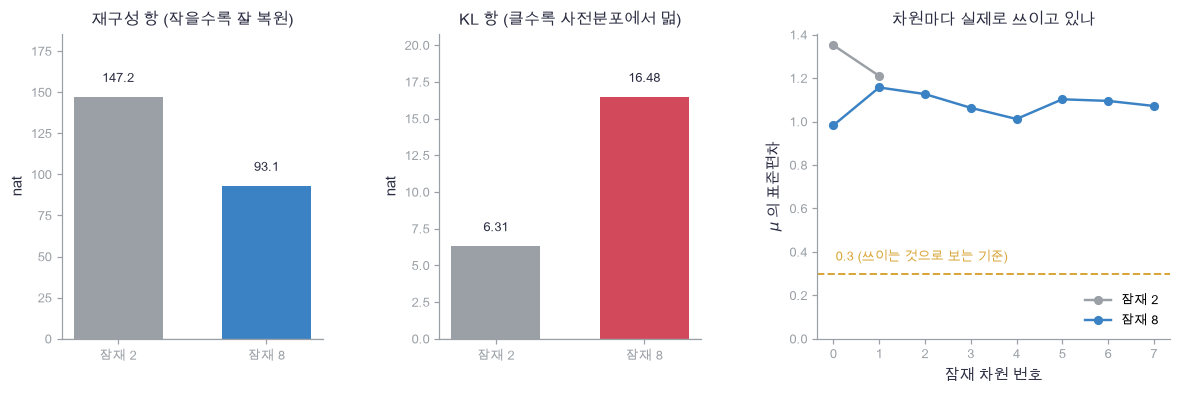

In [66]:
plot_latent_dim_variants(["잠재 2", "잠재 8"], [narrow_terms[0], wide_terms[0]], [narrow_terms[1], wide_terms[1]],
                         [latent_mu.std(axis=0), wide_mu.std(axis=0)])

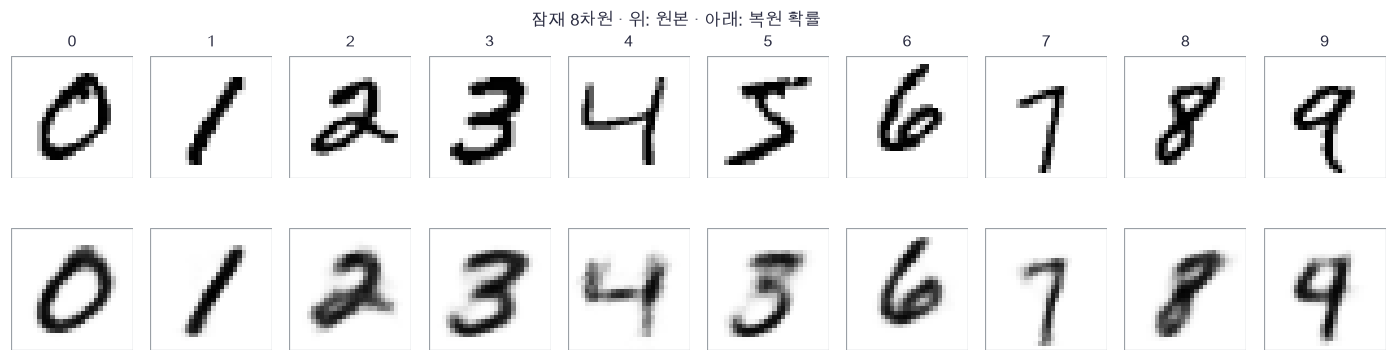

In [67]:
plot_recon_pairs(mnist_examples, vae_reconstruct(mnist_flat, wide_p).reshape(10, 28, 28), mnist_labels,
                 title="잠재 8차원 · 위: 원본 · 아래: 복원 확률")

🔍 **확인** · 예상대로 재구성 항이 내려가고 KL 항이 올라갔습니다. 합은 줄었으니 **하한 자체는 올라간 것**입니다(부호가 반대라서 헷갈리기 쉽습니다. $-\mathrm{ELBO}$가 작아진 것이 하한이 커진 것입니다).
오른쪽 판에서 잠재 8차원 모형은 **여덟 차원을 모두 쓰고 있습니다.** $\mu$의 표준편차가 차원마다 0.3(금색 기준선) 위에 있습니다. 어떤 차원의 표준편차가 0에 가깝다면 그 차원은 $x$와 무관해진 것이고, 5절 📎에서 예고한 posterior collapse입니다.
아래 복원 그림에서 2·4·5·7이 이제 제 모양으로 돌아옵니다. 대신 잠재가 8차원이라 4절처럼 평면에 그려 볼 수는 없습니다. **그림으로 볼 수 있는 것과 잘 되는 것은 다른 이야기**입니다.
gradcheck도 잠재 차원과 상관없이 통과합니다. 3절의 두 갈래 식에는 잠재 차원이 들어 있지 않기 때문입니다.

### ✏️ 준비도 질문 · 다음으로 가기 전, 네 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- **설명:** encoder와 decoder가 각각 무엇을 계산하는지, 그리고 24번에서 관측마다 들고 있던 $(\mu, \ell)$이 왜 신경망 하나로 대체되는지 말할 수 있나요? → 1절
- **수식:** $-\mathrm{ELBO}$의 두 항을 shape와 함께 쓰고, 어느 축을 더하고 어느 축을 평균내는지, 그리고 그 선택이 배치 크기와 화소 수에 어떻게 의존하는지 설명할 수 있나요? → 2절
- **구현:** decoder가 돌려준 $dz$에서 $d\mu$와 $d\ell$을 만드는 두 줄을 직접 쓰고, $\epsilon$을 고정해야 중심차분이 맞는 이유를 말할 수 있나요? → 3절
- **변형:** 잠재 차원이나 관측 모형(Bernoulli → Gaussian)을 바꿔도 KL 항과 backward가 그대로인 이유, 그리고 사전분포에서 뽑은 그림이 이상해질 수 있는 이유를 말할 수 있나요? → 4·5절

다음은 [28 GAN](28_gan.ipynb)입니다. 이 노트북의 decoder는 "잠재 → 이미지" 신경망이고, GAN의 생성기도 같은 모양입니다.
달라지는 것은 **무엇을 최소화하는가**입니다. VAE는 관측의 하한을 올리므로 흐릿하더라도 모든 데이터를 설명하려 하고, GAN은 판별기를 속이려 하므로 선명하지만 일부 모드를 놓칠 수 있습니다. 26번은 이 노트북의 두 항에 $\beta$를 붙이는 설계만 다룹니다.

📎 encoder·decoder와 재매개화로 ELBO를 학습하는 방법은 [Kingma·Welling (2013)](https://arxiv.org/abs/1312.6114)에 정리되어 있습니다. 같은 시기에 [Rezende, Mohamed, Wierstra (2014)](https://arxiv.org/abs/1401.4082)가 같은 아이디어를 따로 내놓았고,
$\beta$로 두 항의 저울을 조정하는 이야기는 [Higgins 등 (2017)](https://openreview.net/forum?id=Sy2fzU9gl)에 있습니다. 이 노트북의 데이터 크기·모델 폭·스텝 수는 설명을 위해 새로 정한 것이며 원논문의 재현 실험이 아닙니다.